In [2]:
# Import packages
import pandas as pd
import numpy as np

import ossify as osy
from standard_transform.datasets import v1dd_ds

from scipy import stats

import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

import sys
from os.path import join as pjoin
from typing import Optional, Union
utils_path = "/root/capsule/code/utils"
sys.path.insert(0, utils_path)

import itertools

import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import tqdm
from connects_common_connectivity.io import DatasetReader, read_synapse_table
from matplotlib import pyplot as plt
from scipy import spatial, stats
from scipy.sparse import csr_array

from paths import resolve_data_root, resolve_dataset_dir

In [3]:
import os
from caveclient import CAVEclient

client = CAVEclient("v1dd_public", server_address="https://global.em.brain.allentech.org", auth_token=os.environ["API_SECRET"])


In [4]:
thal_syn = pd.read_csv('thal_syn.csv')

print("thal axons:", thal_syn["pre_pt_root_id"].nunique())
print("post root IDs:", thal_syn["post_pt_root_id"].nunique())
print("synapses:", len(thal_syn))

thal axons: 97
post root IDs: 321532
synapses: 463661


In [5]:
thal_syn

,id,created,superceded_id,valid,size,pre_pt_supervoxel_id,pre_pt_root_id,post_pt_supervoxel_id,post_pt_root_id,pre_pt_position,post_pt_position,ctr_pt_position
0,282681478,2021-11-19 01:35:28.272045+00:00,NaN,True,2902.0,88397162936966358,864691132647486796,88397162936965005,864691132832053252,[665158 653081 511605],[665332 652761 511380],[665051 653062 511560]
1,324977225,2021-11-18 22:16:58.141699+00:00,NaN,True,739.0,89662287497449724,864691132804540262,89591918753323750,864691132612319611,[709739 598771 182340],[709341 598781 182655],[709555 598810 182430]
2,404535272,2021-11-18 22:03:58.345906+00:00,NaN,True,750.0,93321462999446267,864691132647486796,93321462999447466,864691131718083940,[840058 599654 438525],[839622 599624 438525],[839816 599692 438435]
3,417826507,2021-11-19 02:10:08.767039+00:00,NaN,True,1808.0,93532774786769330,864691132843175686,93532774786771710,864691132612319611,[846732 606385 243180],[847130 606638 243405],[846926 606531 243270]
4,295785734,2021-11-18 22:51:18.353664+00:00,NaN,True,2390.0,88465400438245810,864691132629122108,88535769182411361,864691132022324186,[669610 575520 205425],[670105 575520 205740],[669911 575491 205650]
...,...,...,...,...,...,...,...,...,...,...,...,...
463656,432097798,2021-11-19 00:40:18.412715+00:00,NaN,True,5283.0,94519449503331350,864691132731716336,94519449503338875,864691132842860980,[881875 659425 397890],[882205 659803 398070],[882215 659570 398160]
463657,400168853,2021-11-19 00:27:55.774292+00:00,NaN,True,2630.0,92620042897998710,864691132731716336,92619974178505838,864691132644530230,[814615 679252 309690],[814266 679067 310185],[814305 679242 309960]
463658,307436428,2021-11-19 04:45:30.802793+00:00,NaN,True,903.0,89168607246386510,864691132549572162,89168607246380012,864691132609963587,[694083 557720 345555],[694345 557730 345285],[694044 557604 345330]
463659,376398490,2021-11-19 01:09:06.746304+00:00,NaN,True,1563.0,91980127265041365,864691132836641685,91980127265035005,864691132596158271,[793207 441117 362205],[793246 440865 361800],[793508 440932 362025]


In [6]:
# merge the dataframe to label the cell type (E or I) of post-synaptice neurons
cell_types = client.materialize.query_table(
    "cell_type_multifeature_v1",
)

print(cell_types.columns)
cell_types[[
    "pt_root_id",
    "classification_system",
    "cell_type"
]].head()

ct = cell_types[
    ["pt_root_id", "classification_system", "cell_type"]
].drop_duplicates("pt_root_id")

thal_typed = thal_syn.merge(
    ct,
    left_on="post_pt_root_id",
    right_on="pt_root_id",
    how="inner"
)

# dividing thal_syn into T->E and T -> I
T_E_syn = thal_typed[
    thal_typed["classification_system"] == "excitatory"
].copy()

T_I_syn = thal_typed[
    thal_typed["classification_system"] == "inhibitory"
].copy()

Index(['id', 'created', 'valid', 'target_id', 'classification_system',
       'cell_type', 'id_ref', 'created_ref', 'valid_ref', 'volume',
       'pt_supervoxel_id', 'pt_root_id', 'pt_position', 'bb_start_position',
       'bb_end_position'],
      dtype='object')


In [7]:
# W_TE: thalamocortical axon × E neuron
TE = (
    T_E_syn
    .groupby(["pre_pt_root_id", "post_pt_root_id"])
    .size()
    .rename("n_synapses")
    .reset_index()
)

W_TE = TE.pivot(
    index="pre_pt_root_id",
    columns="post_pt_root_id",
    values="n_synapses"
).fillna(0)

TE_size = (
    T_E_syn
    .groupby(["pre_pt_root_id", "post_pt_root_id"])
    .size()
    .rename("size")
    .reset_index()
)

W_TE_size = TE_size.pivot(
    index="pre_pt_root_id",
    columns="post_pt_root_id",
    values="size"
).fillna(0)


In [8]:
# W_TI
TI = (
    T_I_syn
    .groupby(["pre_pt_root_id", "post_pt_root_id"])
    .size()
    .rename("n_synapses")
    .reset_index()
)


thal_recipient_I = TI["post_pt_root_id"].unique()

thal_recipient_I

array([864691132561636836, 864691132563533028, 864691132574637882, ...,
       864691132984526432, 864691133064998216, 864691133068459977],
      shape=(2752,))

In [9]:
proof = client.materialize.query_table(
    "proofreading_status_and_strategy",
    materialization_version=1196
)

proof_I = proof[
    (proof["status_axon"] == True) &
    (proof["pt_root_id"].isin(thal_recipient_I))
].copy()

I_ids = [
    int(x)
    for x in proof_I["pt_root_id"].dropna().unique()
]

print(len(I_ids))

I_syn = pd.read_csv('I_syn.csv')

416


In [10]:
#i'm interested in those with synaptic target = E
I_syn_typed = I_syn.merge(
    ct,
    left_on="post_pt_root_id",
    right_on="pt_root_id",
    how="inner"
)

I_E_syn = I_syn_typed[
    I_syn_typed["classification_system"] == "excitatory"
].copy()

In [11]:
W_TI = TI.pivot(
    index="pre_pt_root_id",
    columns="post_pt_root_id",
    values="n_synapses"
).fillna(0)

IE = (
    I_E_syn
    .groupby(["pre_pt_root_id", "post_pt_root_id"])
    .size()
    .rename("n_synapses")
    .reset_index()
)

W_IE = IE.pivot(
    index="pre_pt_root_id",
    columns="post_pt_root_id",
    values="n_synapses"
).fillna(0)

In [12]:
# Use the complete T × E universe represented by W_TE.
# Do NOT intersect the E columns with FFI_paths: E neurons absent from
# FFI_paths are valid FFI-negative cases and must remain in the denominator.
Direct = W_TE.copy()


common_I = W_TI.columns.intersection(W_IE.index)

W_TI2 = W_TI.loc[:, common_I]
W_IE2 = W_IE.loc[common_I, :]

A = (W_TI2 > 0).astype(int)
B = (W_IE2 > 0).astype(int)

FFI_paths = A @ B

FFI = FFI_paths.reindex(
    index=Direct.index,
    columns=Direct.columns,
    fill_value=0
)

assert Direct.index.equals(FFI.index)
assert Direct.columns.equals(FFI.columns)
print("Aligned Direct and FFI matrices:", Direct.shape)

Aligned Direct and FFI matrices: (97, 17397)


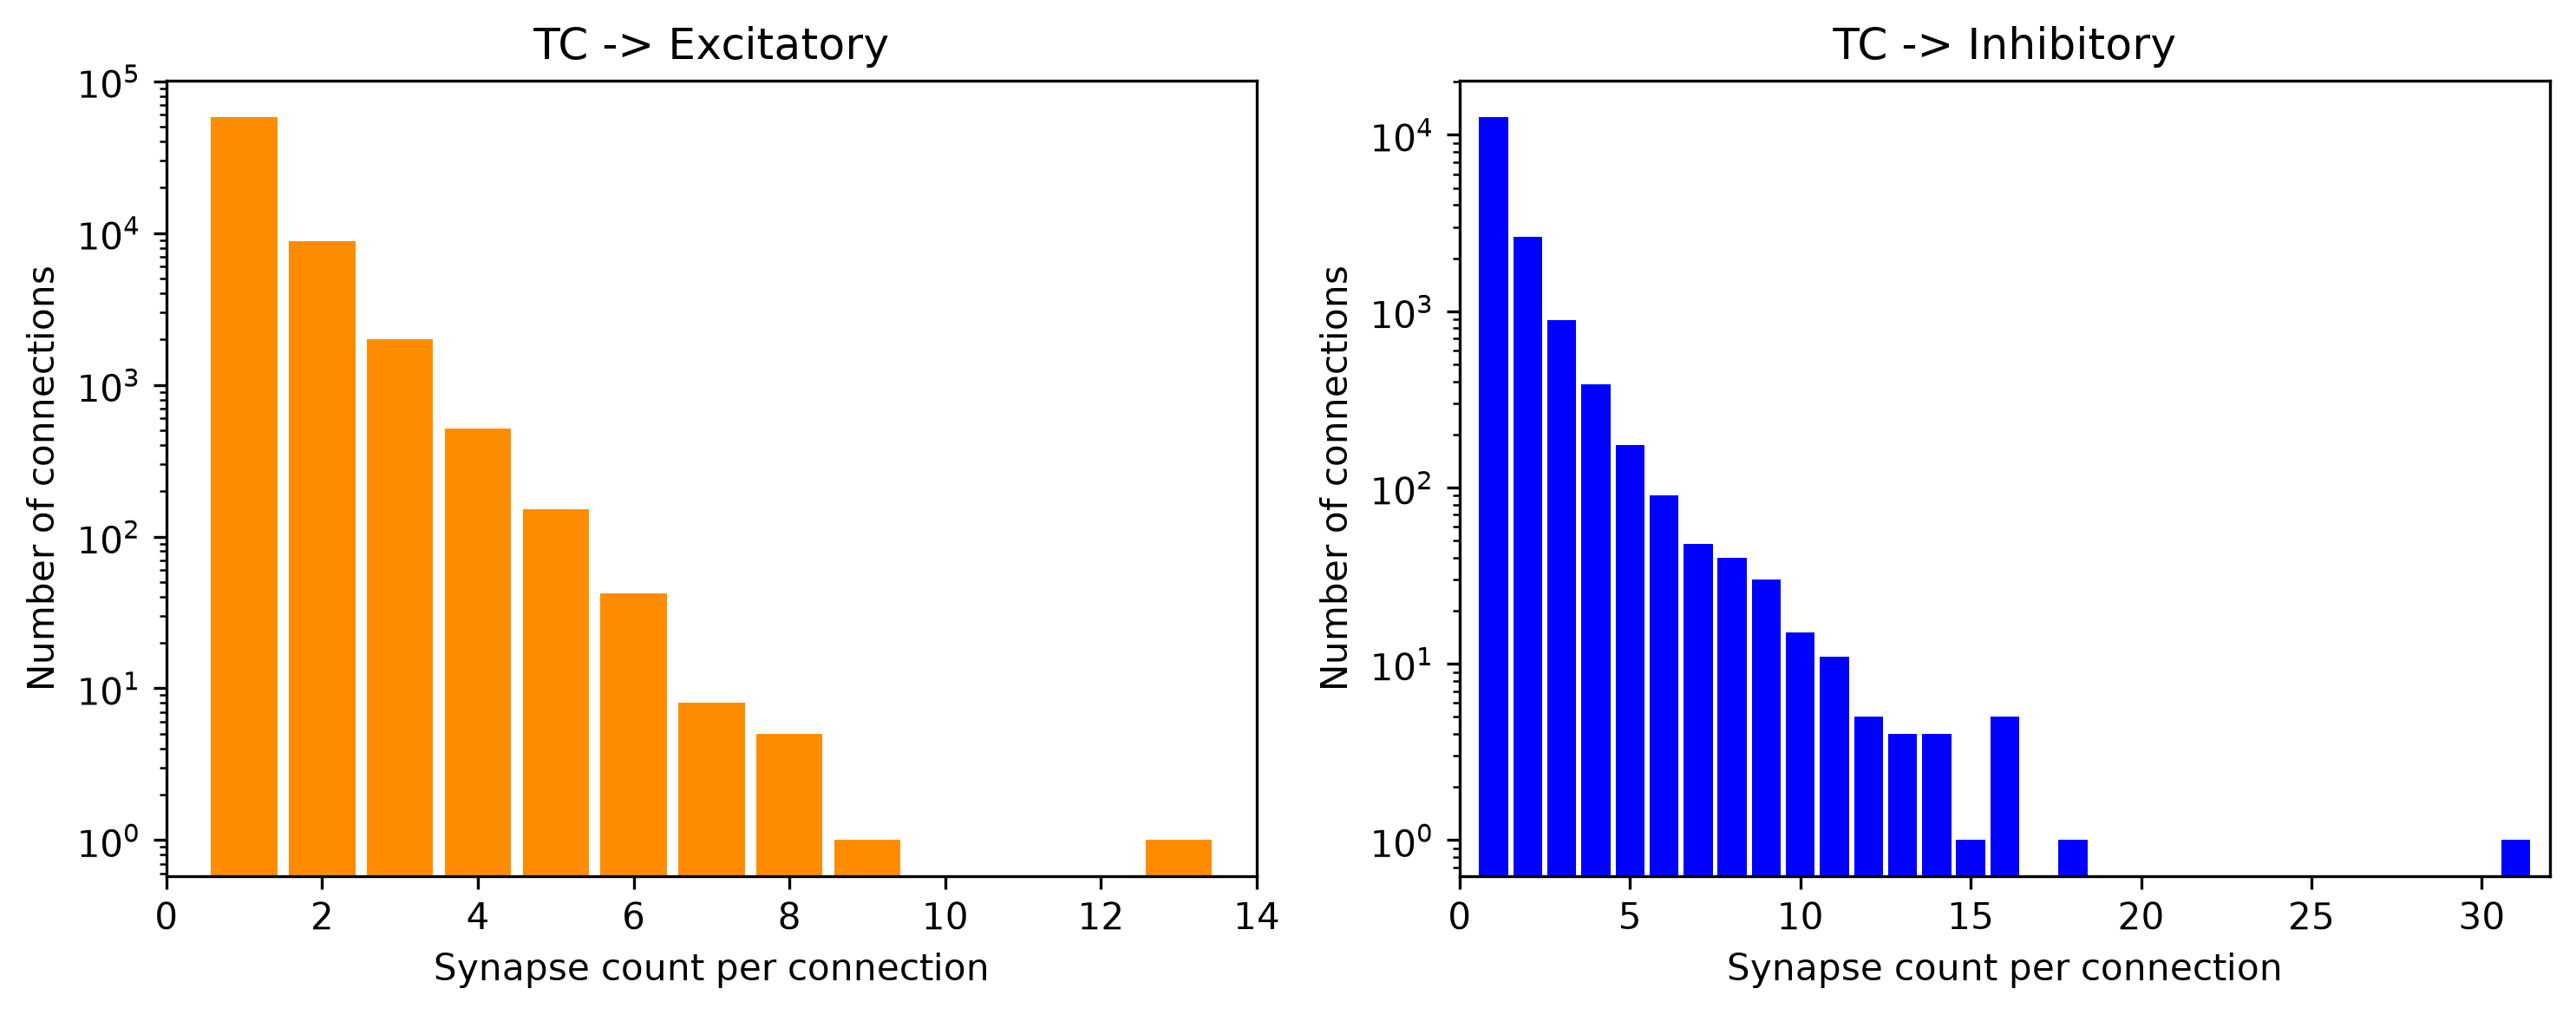

In [13]:
# 非ゼロセルの抽出
synapse_counts_TE = W_TE.stack()
synapse_counts_TE = synapse_counts_TE[synapse_counts_TE != 0]

synapse_counts_TI = W_TI.stack()
synapse_counts_TI = synapse_counts_TI[synapse_counts_TI != 0]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=300)

# Define explicit integer bin boundaries centered on count values
max_TE = int(synapse_counts_TE.max())
bins_TE = np.arange(0.5, max_TE + 1.5, 1)

# Distribution of synapse counts (TE)
axes[0].hist(
    synapse_counts_TE,
    bins=bins_TE,
    color="darkorange",
    rwidth=0.85  # Set to 1.0 or remove for solid touching bars
)
axes[0].set_xlabel("Synapse count per connection")
axes[0].set_ylabel("Number of connections")
axes[0].set_title("TC -> Excitatory")
axes[0].set_xlim(0, max_TE + 1)
axes[0].set_yscale("log")

# Define explicit integer bin boundaries for TI
max_TI = int(synapse_counts_TI.max())
bins_TI = np.arange(0.5, max_TI + 1.5, 1)

# Distribution of synapse counts (TI)
axes[1].hist(
    synapse_counts_TI,
    bins=bins_TI,
    color="blue",
    rwidth=0.85
)
axes[1].set_xlabel("Synapse count per connection")
axes[1].set_ylabel("Number of connections")
axes[1].set_title("TC -> Inhibitory")
axes[1].set_xlim(0, max_TI + 1)
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

In [14]:
target_value = 31

positions = synapse_counts_TI.eq(target_value)
positions = positions[positions].index.tolist()

print(positions)

target_value = 13

positions = synapse_counts_TE.eq(target_value)
positions = positions[positions].index.tolist()

print(positions)

[(864691132645737598, 864691132785664338)]
[(864691132628102040, 864691132834733476)]


In [15]:
from caveclient import CAVEclient
from nglui.statebuilder import ViewerState

client = CAVEclient("v1dd_public", server_address="https://global.em.brain.allentech.org", auth_token=os.environ["API_SECRET"])

vs = ViewerState(client=client).add_layers_from_client()

pre = 864691132628102040
post =864691132834733476

vs = vs.add_segments([pre, post])

synapses = client.materialize.synapse_query(
    pre_ids=pre, post_ids=post, desired_resolution=[1, 1, 1]
)

vs = vs.add_points(
    data=synapses, point_column="ctr_pt_position", data_resolution=[1, 1, 1]
)

vs.to_browser(shorten=True)

/opt/conda/lib/python3.12/site-packages/nglui/statebuilder/source_info.py:68: UserWarning: CloudVolume is not available. Cannot get source information for precomputed://gs://v1dd_imagery/image/aligned_image.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/nglui/statebuilder/source_info.py:68: UserWarning: CloudVolume is not available. Cannot get source information for graphene://https://api.em.brain.allentech.org/segmentation/table/v1dd_public.
  warnings.warn(
(node:49625) [DEP0169] DeprecationWarning: `url.parse()` behavior is not standardized and prone to errors that have security implications. Use the WHATWG URL API instead. CVEs are not issued for `url.parse()` vulnerabilities.
(Use `node --trace-deprecation ...` to show where the warning was created)


'https://spelunker.cave-explorer.org/#!middleauth+https://global.em.brain.allentech.org/nglstate/api/v1/5728751555969024'

In [16]:
import caveclient
from nglui import statebuilder
# Get a root id of a specific neuron
root_id = client.materialize.query_table(
    'nucleus_detection_v0',
    filter_equal_dict={'id': 864691132628102040}
)['pt_root_id']

statebuilder.helpers.make_neuron_neuroglancer_link(
    client,
    root_id,
    show_inputs=True,
    show_outputs=True,
)

/opt/conda/lib/python3.12/site-packages/nglui/statebuilder/source_info.py:68: UserWarning: CloudVolume is not available. Cannot get source information for precomputed://gs://v1dd_imagery/image/aligned_image.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/nglui/statebuilder/source_info.py:68: UserWarning: CloudVolume is not available. Cannot get source information for graphene://https://api.em.brain.allentech.org/segmentation/table/v1dd_public.
  warnings.warn(


In [17]:
thal_syn

,id,created,superceded_id,valid,size,pre_pt_supervoxel_id,pre_pt_root_id,post_pt_supervoxel_id,post_pt_root_id,pre_pt_position,post_pt_position,ctr_pt_position
0,282681478,2021-11-19 01:35:28.272045+00:00,NaN,True,2902.0,88397162936966358,864691132647486796,88397162936965005,864691132832053252,[665158 653081 511605],[665332 652761 511380],[665051 653062 511560]
1,324977225,2021-11-18 22:16:58.141699+00:00,NaN,True,739.0,89662287497449724,864691132804540262,89591918753323750,864691132612319611,[709739 598771 182340],[709341 598781 182655],[709555 598810 182430]
2,404535272,2021-11-18 22:03:58.345906+00:00,NaN,True,750.0,93321462999446267,864691132647486796,93321462999447466,864691131718083940,[840058 599654 438525],[839622 599624 438525],[839816 599692 438435]
3,417826507,2021-11-19 02:10:08.767039+00:00,NaN,True,1808.0,93532774786769330,864691132843175686,93532774786771710,864691132612319611,[846732 606385 243180],[847130 606638 243405],[846926 606531 243270]
4,295785734,2021-11-18 22:51:18.353664+00:00,NaN,True,2390.0,88465400438245810,864691132629122108,88535769182411361,864691132022324186,[669610 575520 205425],[670105 575520 205740],[669911 575491 205650]
...,...,...,...,...,...,...,...,...,...,...,...,...
463656,432097798,2021-11-19 00:40:18.412715+00:00,NaN,True,5283.0,94519449503331350,864691132731716336,94519449503338875,864691132842860980,[881875 659425 397890],[882205 659803 398070],[882215 659570 398160]
463657,400168853,2021-11-19 00:27:55.774292+00:00,NaN,True,2630.0,92620042897998710,864691132731716336,92619974178505838,864691132644530230,[814615 679252 309690],[814266 679067 310185],[814305 679242 309960]
463658,307436428,2021-11-19 04:45:30.802793+00:00,NaN,True,903.0,89168607246386510,864691132549572162,89168607246380012,864691132609963587,[694083 557720 345555],[694345 557730 345285],[694044 557604 345330]
463659,376398490,2021-11-19 01:09:06.746304+00:00,NaN,True,1563.0,91980127265041365,864691132836641685,91980127265035005,864691132596158271,[793207 441117 362205],[793246 440865 361800],[793508 440932 362025]


In [18]:
# Audit the selection-bias correction.
missing_E_from_raw_FFI = W_TE.columns.difference(FFI_paths.columns)
missing_T_from_raw_FFI = W_TE.index.difference(FFI_paths.index)

print(f"E neurons retained: {Direct.shape[1]:,} / {W_TE.shape[1]:,}")
print(f"T axons retained: {Direct.shape[0]:,} / {W_TE.shape[0]:,}")
print(f"E neurons absent from raw FFI_paths and zero-filled: {len(missing_E_from_raw_FFI):,}")
print(f"T axons absent from raw FFI_paths and zero-filled: {len(missing_T_from_raw_FFI):,}")

# All W_TE columns must still be present after alignment.
assert len(W_TE.columns.difference(FFI.columns)) == 0

E neurons retained: 17,397 / 17,397
T axons retained: 97 / 97
E neurons absent from raw FFI_paths and zero-filled: 1,427
T axons absent from raw FFI_paths and zero-filled: 0


In [19]:
direct_exists = Direct.gt(0)
ffi_exists = FFI.gt(0)

p_ffi_given_direct = (
    (direct_exists & ffi_exists).sum().sum()
    / direct_exists.sum().sum()
)

print(f"Overall P(FFI | direct T→E) = {p_ffi_given_direct:.3f}")

Overall P(FFI | direct T→E) = 0.889


In [20]:
# Excitatory-cell layer annotation.
E_meta = (
    ct.loc[ct["classification_system"] == "excitatory",
           ["pt_root_id", "cell_type"]]
    .drop_duplicates("pt_root_id")
    .copy()
)
E_meta["layer"] = E_meta["cell_type"].str.extract(r"^(L[2-6])")

layer_order = ["L2", "L3", "L4", "L5", "L6"]
e_to_layer = E_meta.set_index("pt_root_id")["layer"]
layer_by_e = pd.Series(Direct.columns.map(e_to_layer), index=Direct.columns)

print("Direct-target E neurons without an L2–L6 label:", layer_by_e.isna().sum())

Direct-target E neurons without an L2–L6 label: 0


In [21]:
# Pair-weighted conditional probability within each cortical layer.
# Every directly connected T–E pair is counted; raw-FFI-missing E cells
# remain present as FFI=False because of the reindexing above.
layer_rows = []

for layer in layer_order:
    e_ids = layer_by_e.index[layer_by_e.eq(layer)]
    direct_layer = direct_exists.loc[:, e_ids]
    ffi_layer = ffi_exists.loc[:, e_ids]

    n_direct = int(direct_layer.to_numpy().sum())
    n_both = int((direct_layer & ffi_layer).to_numpy().sum())

    layer_rows.append({
        "layer": layer,
        "p_ffi_given_direct": n_both / n_direct if n_direct else np.nan,
        "n_direct_and_ffi": n_both,
        "n_direct": n_direct,
        "n_E_cells": len(e_ids),
    })

layer_prob = pd.DataFrame(layer_rows)
layer_prob

,layer,p_ffi_given_direct,n_direct_and_ffi,n_direct,n_E_cells
0,L2,0.970436,11029,11365,2345
1,L3,0.934220,27126,29036,5121
2,L4,0.875322,16674,19049,4594
3,L5,0.810487,1963,2422,1201
4,L6,0.664914,5310,7986,4136


In [22]:
# Per-thalamic-axon fractions prevent highly connected axons from
# dominating the visual comparison across layers.
per_t_rows = []

for layer in layer_order:
    e_ids = layer_by_e.index[layer_by_e.eq(layer)]
    direct_layer = direct_exists.loc[:, e_ids]
    ffi_layer = ffi_exists.loc[:, e_ids]

    n_direct_per_t = direct_layer.sum(axis=1)
    n_both_per_t = (direct_layer & ffi_layer).sum(axis=1)
    valid = n_direct_per_t.gt(0)

    per_t_rows.append(pd.DataFrame({
        "thal_id": n_direct_per_t.index[valid],
        "layer": layer,
        "p_ffi_given_direct": (n_both_per_t[valid] / n_direct_per_t[valid]).to_numpy(),
        "n_direct": n_direct_per_t[valid].to_numpy(),
    }))

per_t_layer = pd.concat(per_t_rows, ignore_index=True)
per_t_layer.groupby("layer")["p_ffi_given_direct"].describe().reindex(layer_order)

,count,mean,std,min,25%,50%,75%,max
layer,,,,,,,,
L2,95.0,0.949239,0.092497,0.25000,0.937500,0.971963,0.995544,1.000000
L3,96.0,0.939807,0.045851,0.78135,0.911612,0.948896,0.976014,1.000000
L4,97.0,0.855020,0.155924,0.00000,0.821229,0.897898,0.941558,1.000000
L5,96.0,0.794807,0.165233,0.00000,0.716471,0.827134,0.923077,1.000000
L6,96.0,0.632694,0.186505,0.00000,0.553459,0.664729,0.750856,0.939759


In [23]:
per_t_layer

,thal_id,layer,p_ffi_given_direct,n_direct
0,864691132537321562,L2,0.911765,34
1,864691132549572162,L2,0.993289,149
2,864691132572564252,L2,0.901840,163
3,864691132582739474,L2,0.970588,68
4,864691132582742802,L2,0.666667,6
...,...,...,...,...
475,864691132970239597,L6,0.682927,41
476,864691133001102261,L6,0.529412,51
477,864691133050913636,L6,0.556962,79
478,864691133067427033,L6,0.650000,40


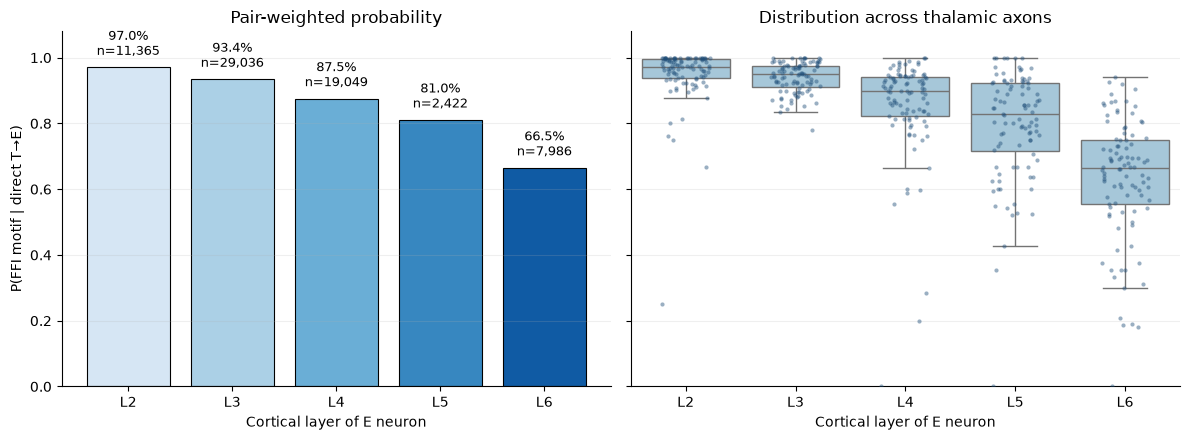

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
colors = sns.color_palette("Blues", n_colors=len(layer_order))

# A: each direct T–E pair has equal weight
bars = axes[0].bar(
    layer_prob["layer"],
    layer_prob["p_ffi_given_direct"],
    color=colors,
    edgecolor="black",
    linewidth=0.8,
)
axes[0].set_title("Pair-weighted probability")
axes[0].set_xlabel("Cortical layer of E neuron")
axes[0].set_ylabel("P(FFI motif | direct T→E)")

for bar, p, n in zip(
    bars, layer_prob["p_ffi_given_direct"], layer_prob["n_direct"]
):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        min(p + 0.025, 1.02),
        f"{p:.1%}\nn={n:,}",
        ha="center", va="bottom", fontsize=9,
    )

# B: each thalamic axon has equal visual weight (robustness to skewed degree).
sns.boxplot(
    data=per_t_layer, x="layer", y="p_ffi_given_direct",
    order=layer_order, color="#9ecae1", fliersize=0, ax=axes[1],
)
sns.stripplot(
    data=per_t_layer, x="layer", y="p_ffi_given_direct",
    order=layer_order, color="#1f4e79", alpha=0.45, size=3,
    jitter=0.22, ax=axes[1],
)
axes[1].set_title("Distribution across thalamic axons")
axes[1].set_xlabel("Cortical layer of E neuron")
axes[1].set_ylabel("")

for ax in axes:
    ax.set_ylim(0, 1.08)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.2)


plt.tight_layout()
plt.show()

In [25]:
# Weighted two-step path strength: sum_i n_TI(t,i) * n_IE(i,e).
FFI_weighted_raw = W_TI2 @ W_IE2
FFI_weighted = FFI_weighted_raw.reindex(
    index=Direct.index, columns=Direct.columns, fill_value=0
)

assert Direct.index.equals(FFI_weighted.index)
assert Direct.columns.equals(FFI_weighted.columns)

# Keep only directly connected pairs. This retains FFI=0 negative cases,
# while avoiding the enormous mass of pairs with Direct=0.
direct_array = Direct.to_numpy()
ffi_weighted_array = FFI_weighted.to_numpy()
t_idx, e_idx = np.nonzero(direct_array > 0)

synapse_pair_df = pd.DataFrame({
    "thal_id": Direct.index.to_numpy()[t_idx],
    "e_id": Direct.columns.to_numpy()[e_idx],
    "direct_synapses": direct_array[t_idx, e_idx].astype(int),
    "weighted_path_strength": ffi_weighted_array[t_idx, e_idx],
})
synapse_pair_df["layer"] = synapse_pair_df["e_id"].map(e_to_layer)
synapse_pair_df = synapse_pair_df.loc[
    synapse_pair_df["layer"].isin(layer_order)
].copy()

synapse_distribution_summary = (
    synapse_pair_df.groupby("layer", observed=True)
    .agg(
        n_direct_pairs=("weighted_path_strength", "size"),
        median_direct_synapses=("direct_synapses", "median"),
        median_weighted_path_strength=("weighted_path_strength", "median"),
        fraction_ffi_zero=("weighted_path_strength", lambda x: x.eq(0).mean()),
    )
    .reindex(layer_order)
)
synapse_distribution_summary

,n_direct_pairs,median_direct_synapses,median_weighted_path_strength,fraction_ffi_zero
layer,,,,
L2,11365,1.0,36.0,0.029564
L3,29036,1.0,32.0,0.065780
L4,19049,1.0,21.0,0.124678
L5,2422,1.0,7.0,0.189513
L6,7986,1.0,2.0,0.335086


(11365,) (11365,)


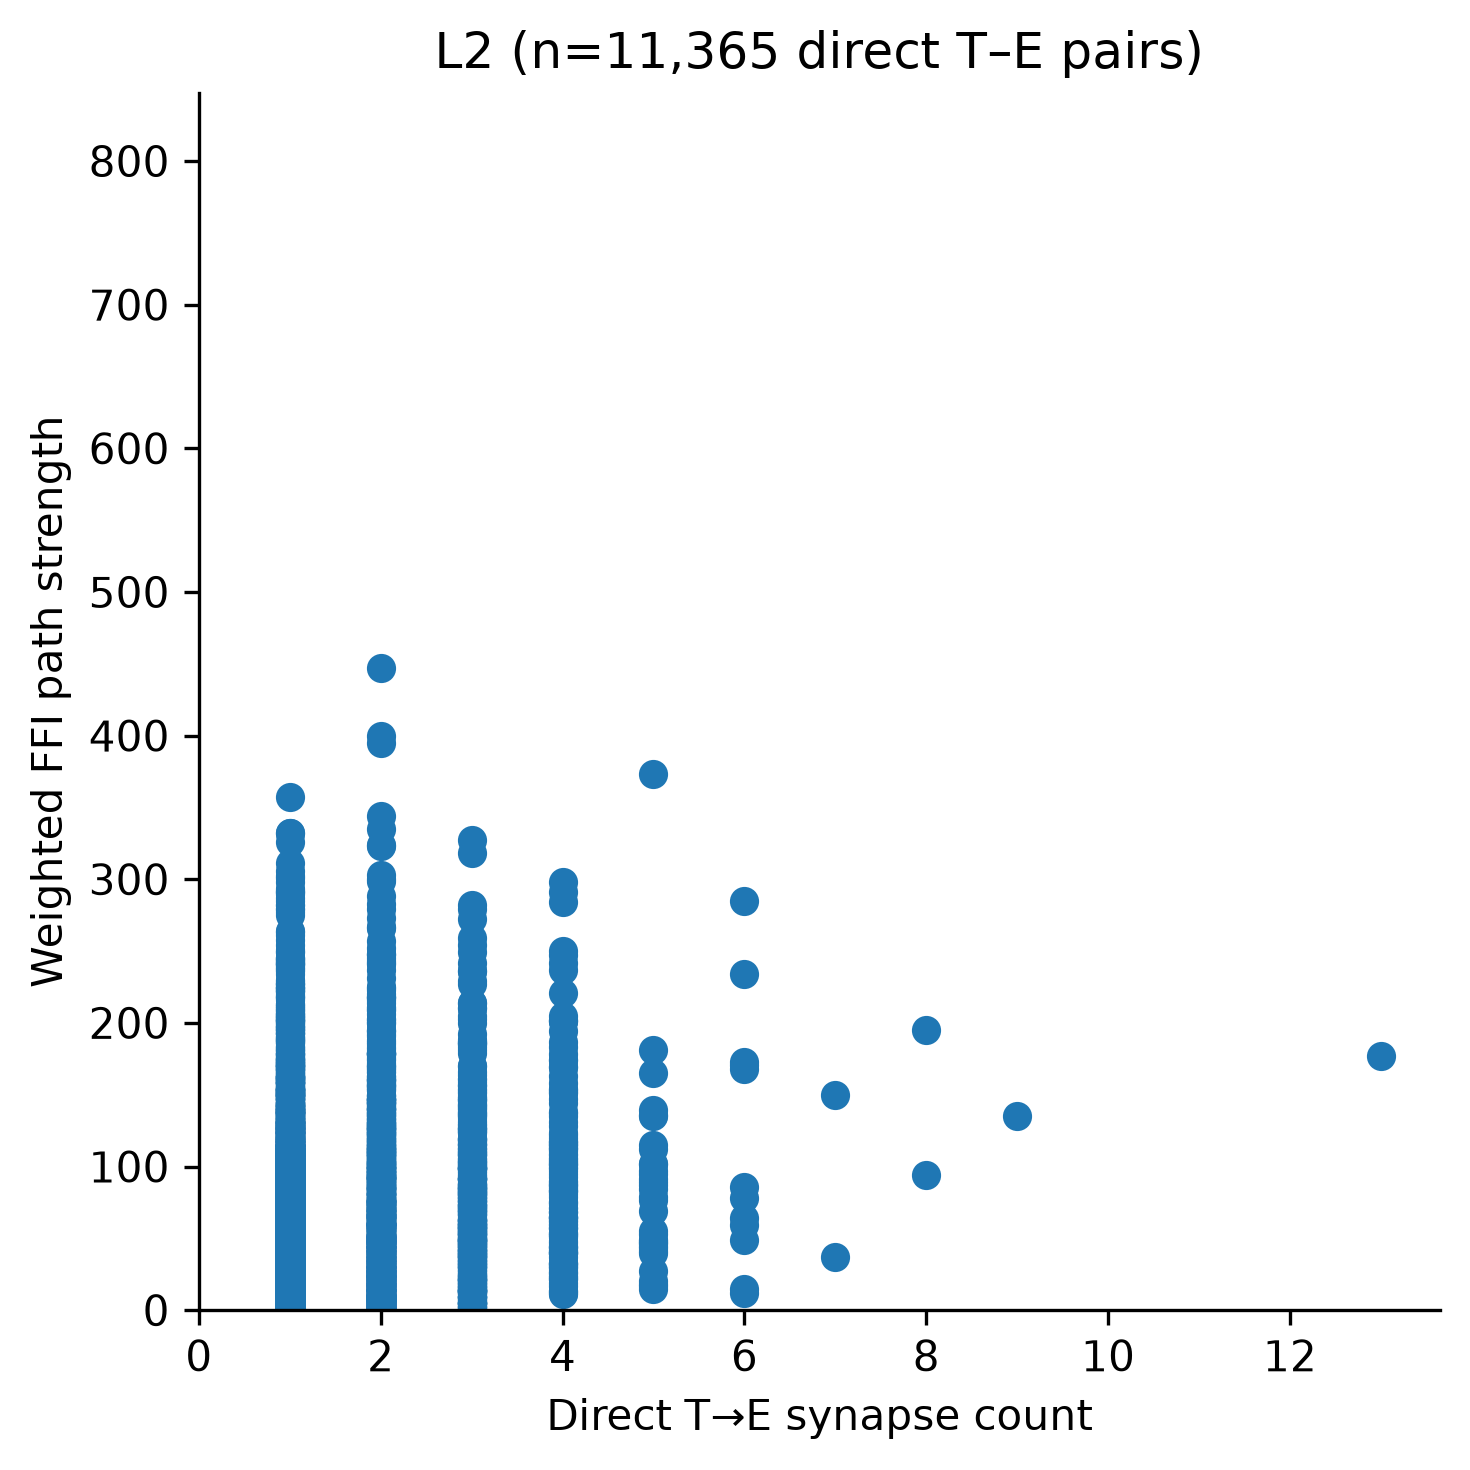

(29036,) (29036,)


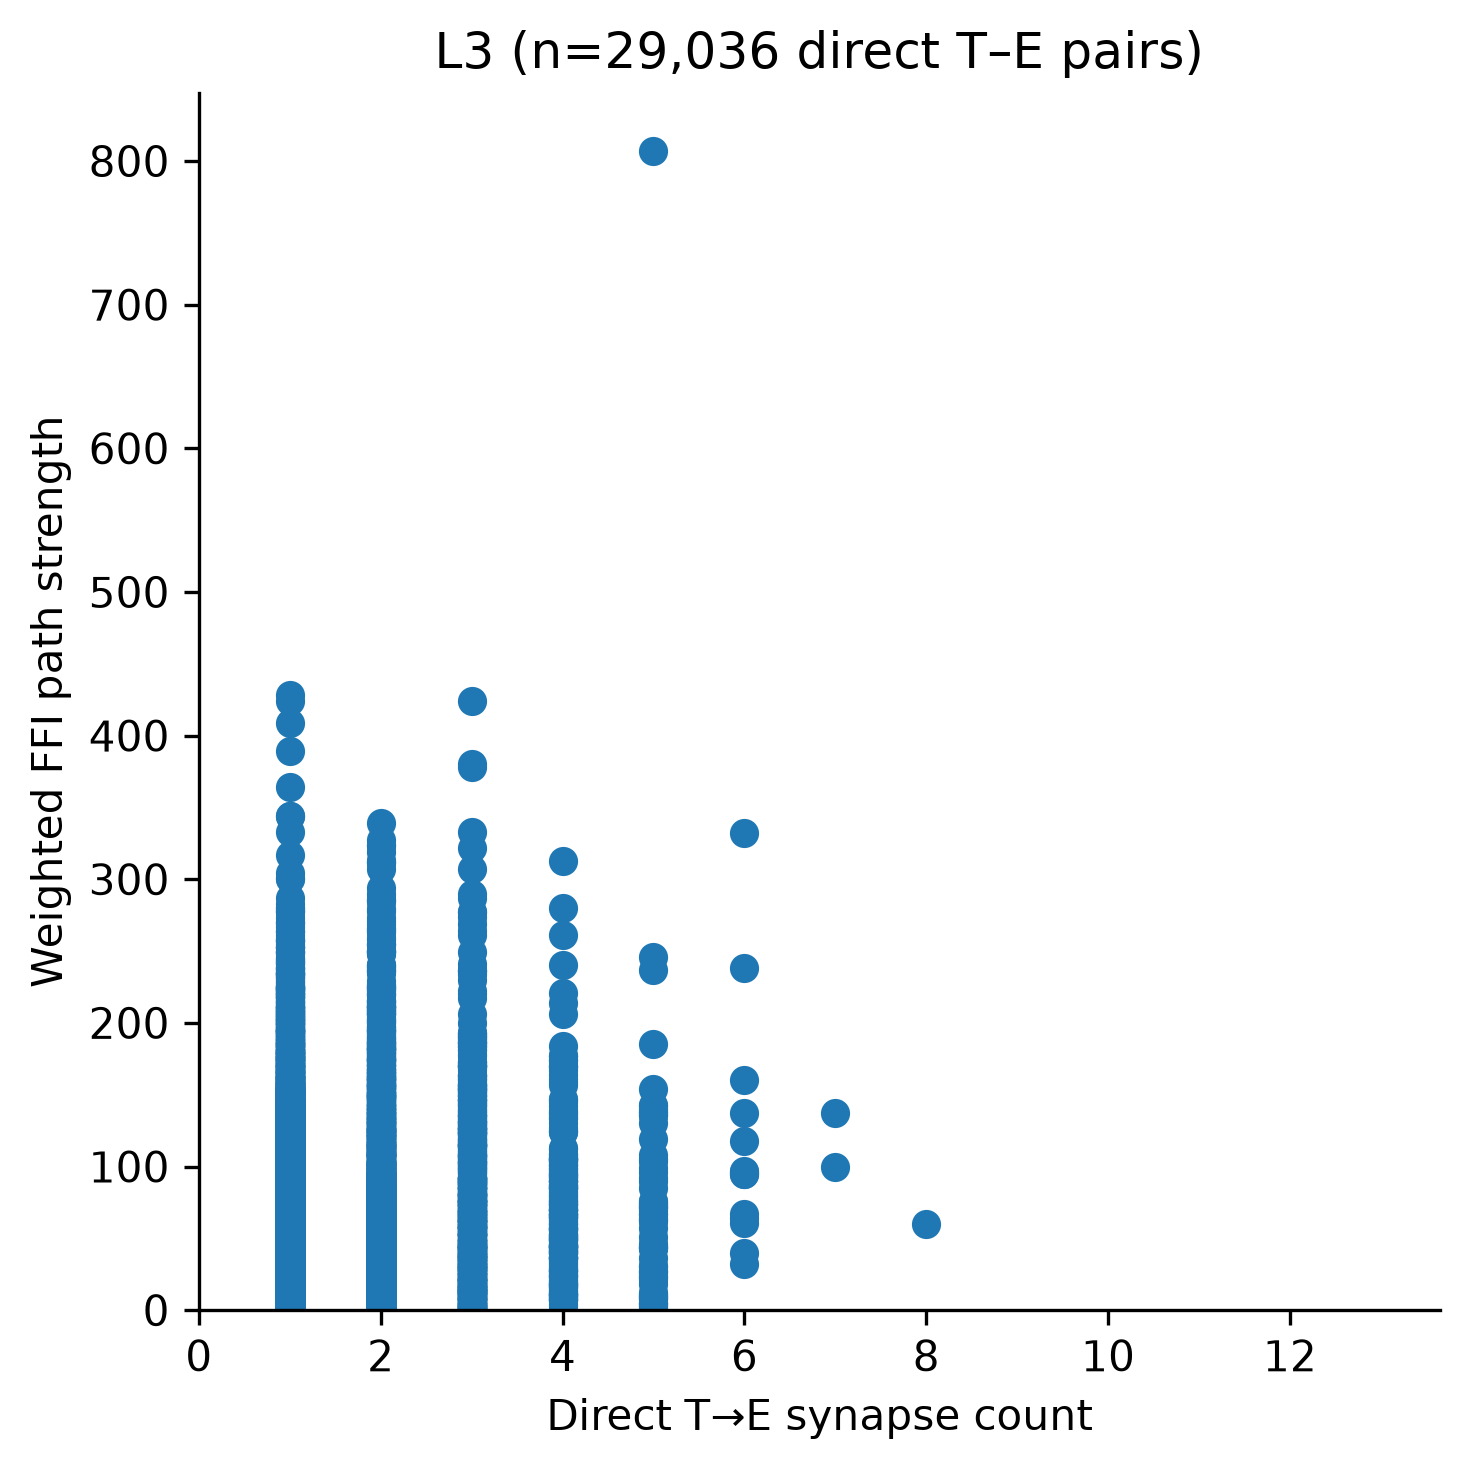

(19049,) (19049,)


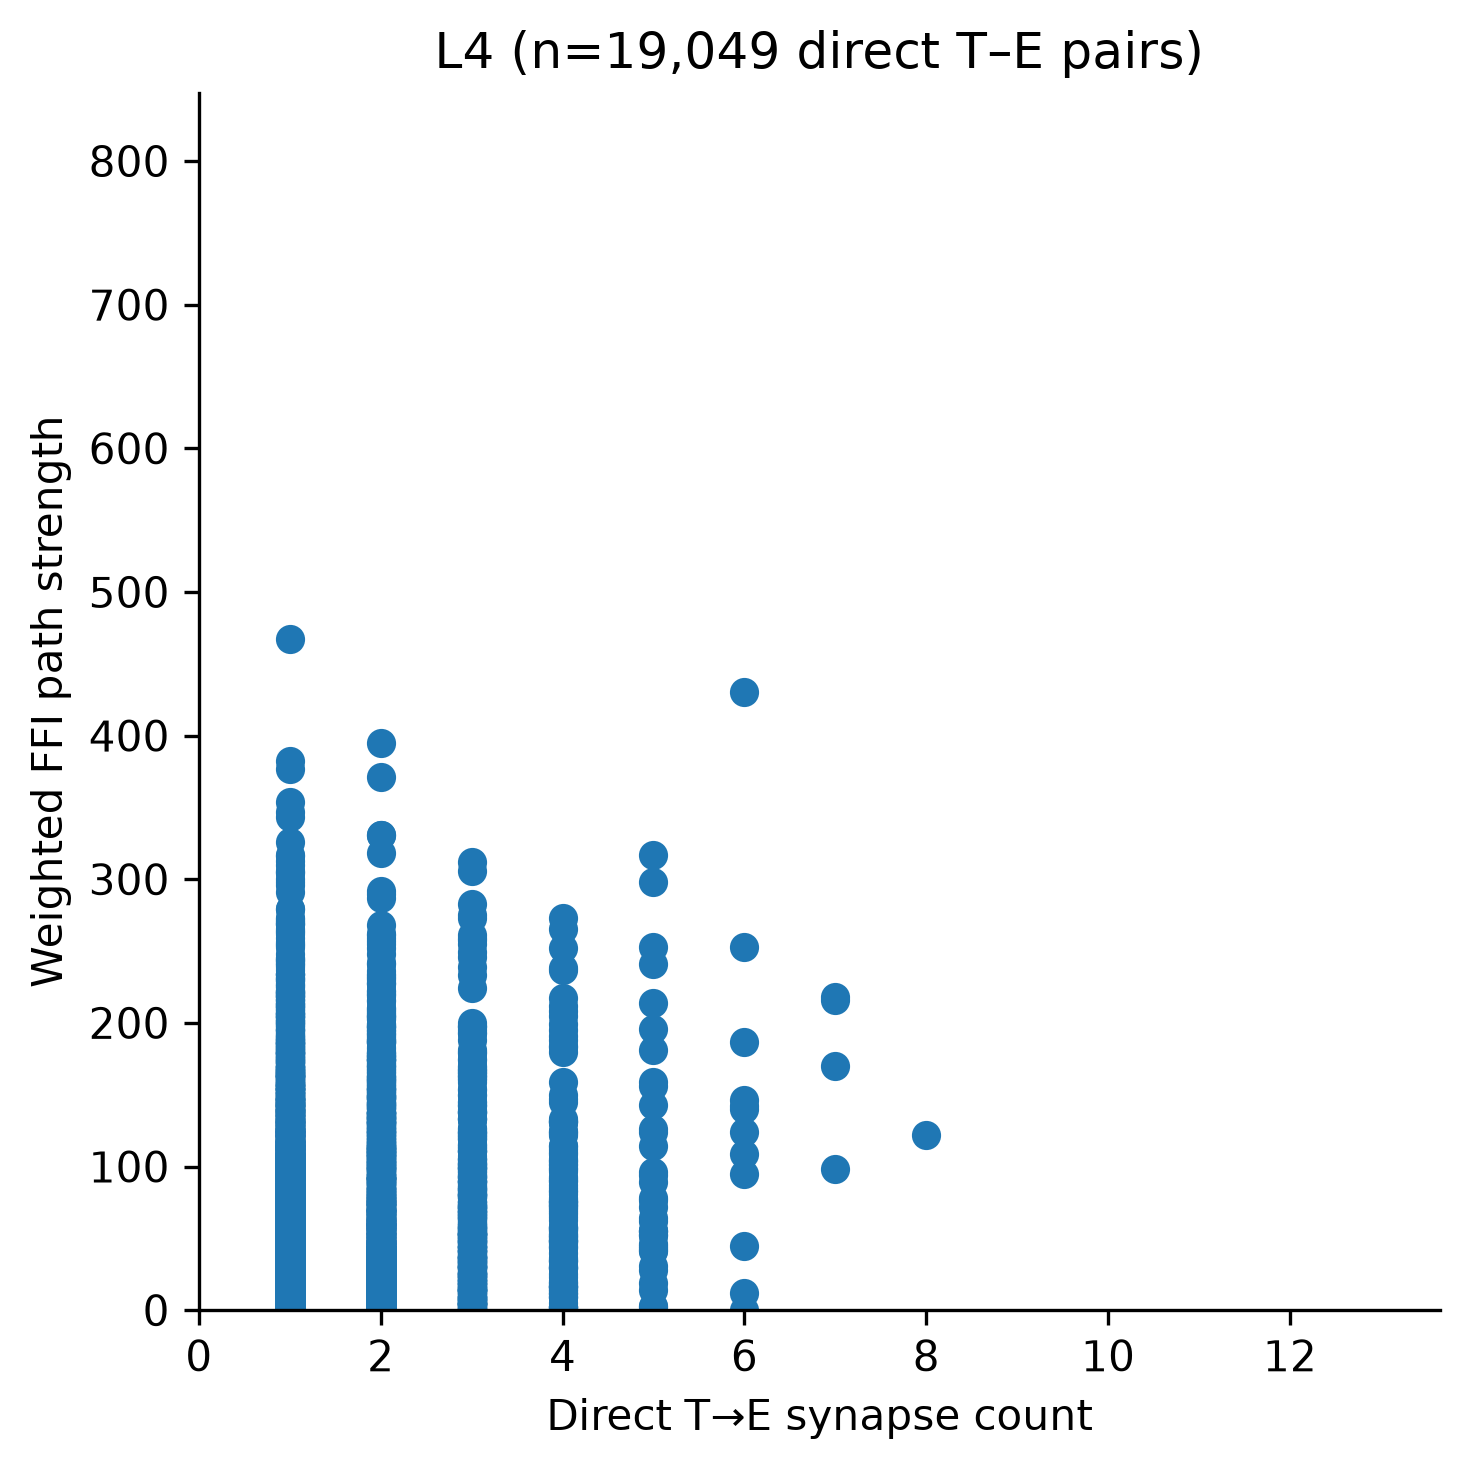

(2422,) (2422,)


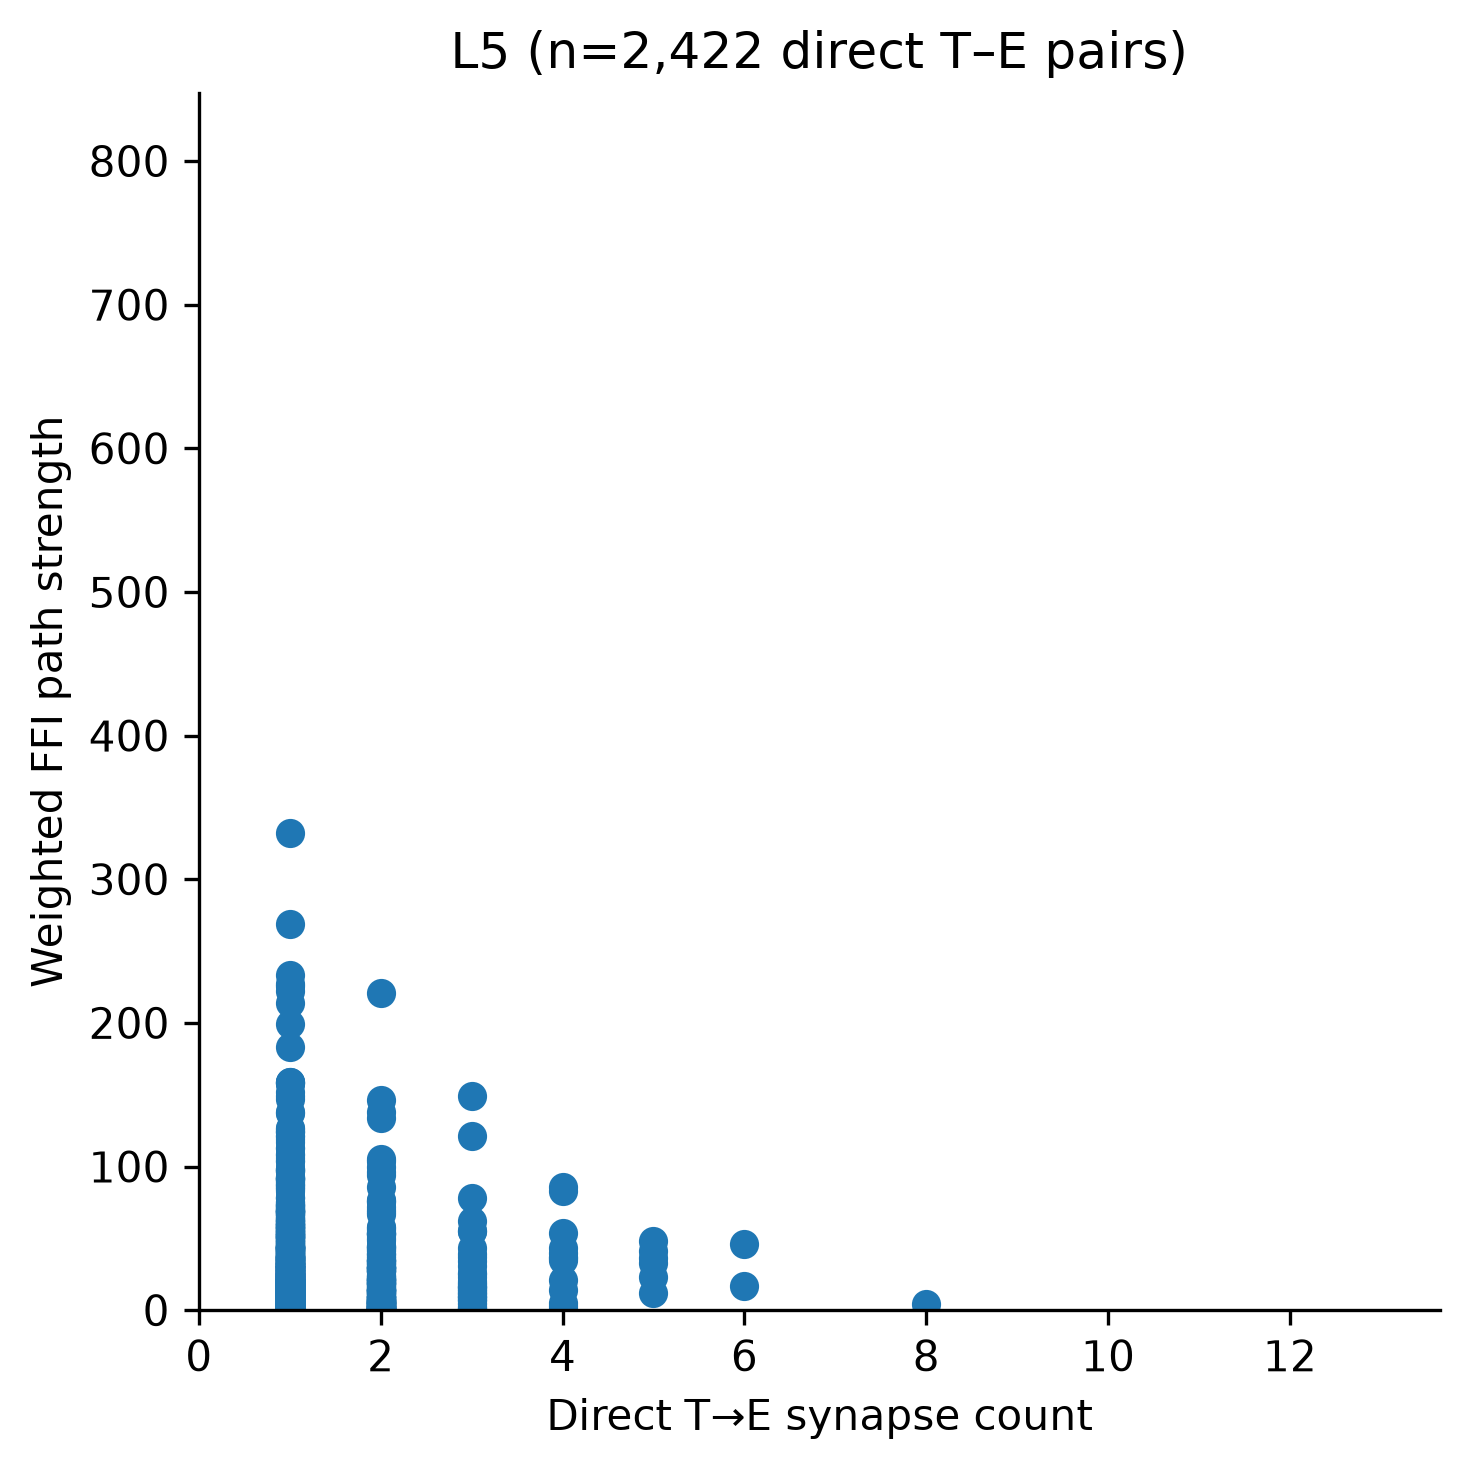

(7986,) (7986,)


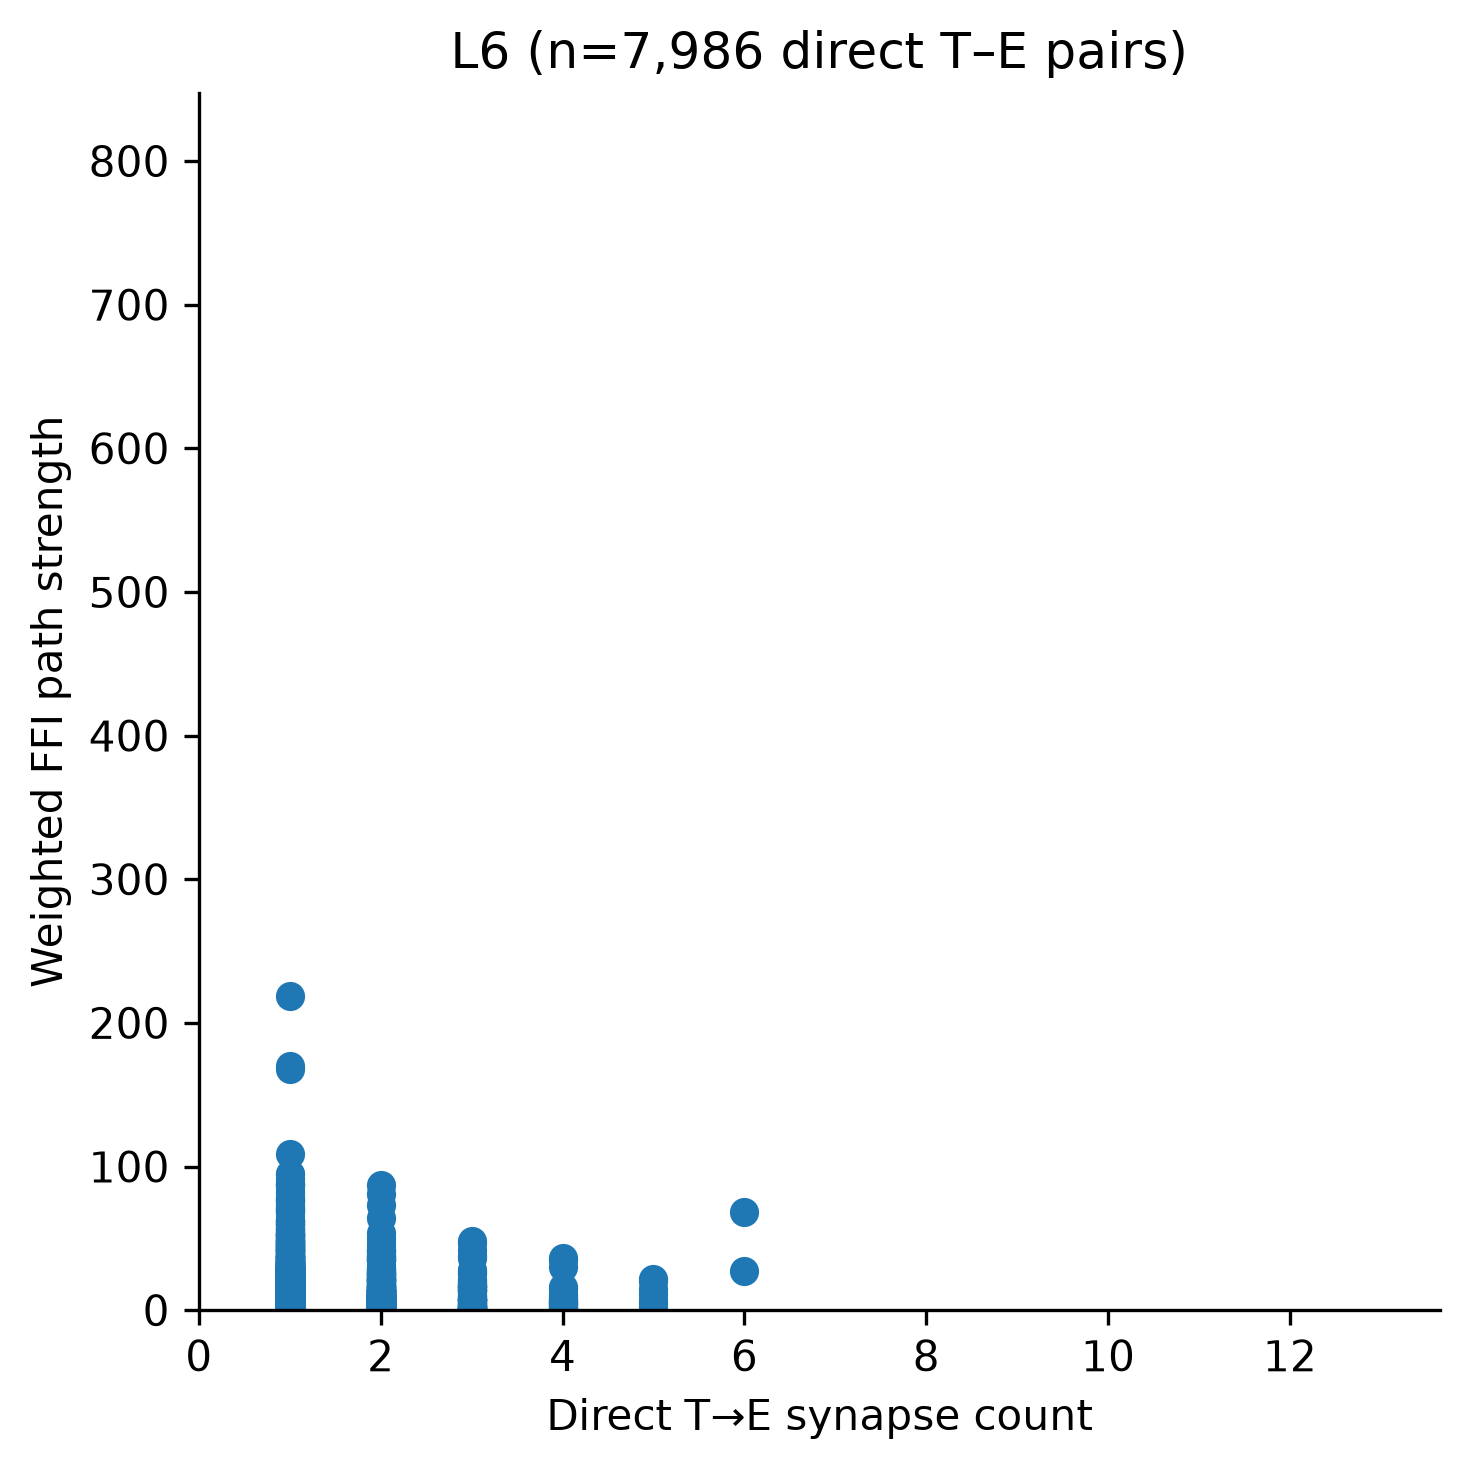

In [26]:
max_direct = int(synapse_pair_df["direct_synapses"].max())
max_weighted = float(synapse_pair_df["weighted_path_strength"].max())

# One plain scatter plot per layer, with common axis limits.
for layer in layer_order:
    layer_df = synapse_pair_df.loc[synapse_pair_df["layer"] == layer]
    if layer_df.empty:
        continue
    
    print(layer_df["direct_synapses"].shape, layer_df["weighted_path_strength"].shape)
    fig, ax = plt.subplots(figsize=(5,5), dpi =300)
    ax.scatter(
        layer_df["direct_synapses"],
        layer_df["weighted_path_strength"],
        # s=12, alpha=0.25, color="tab:blue", edgecolors="none",
        # rasterized=True,
    )
    ax.set_xlim(0, max_direct * 1.05)
    ax.set_ylim(0, max_weighted * 1.05 if max_weighted > 0 else 1)
    ax.set_xlabel("Direct T→E synapse count")
    ax.set_ylabel("Weighted FFI path strength")
    ax.set_title(f"{layer} (n={len(layer_df):,} direct T–E pairs)")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

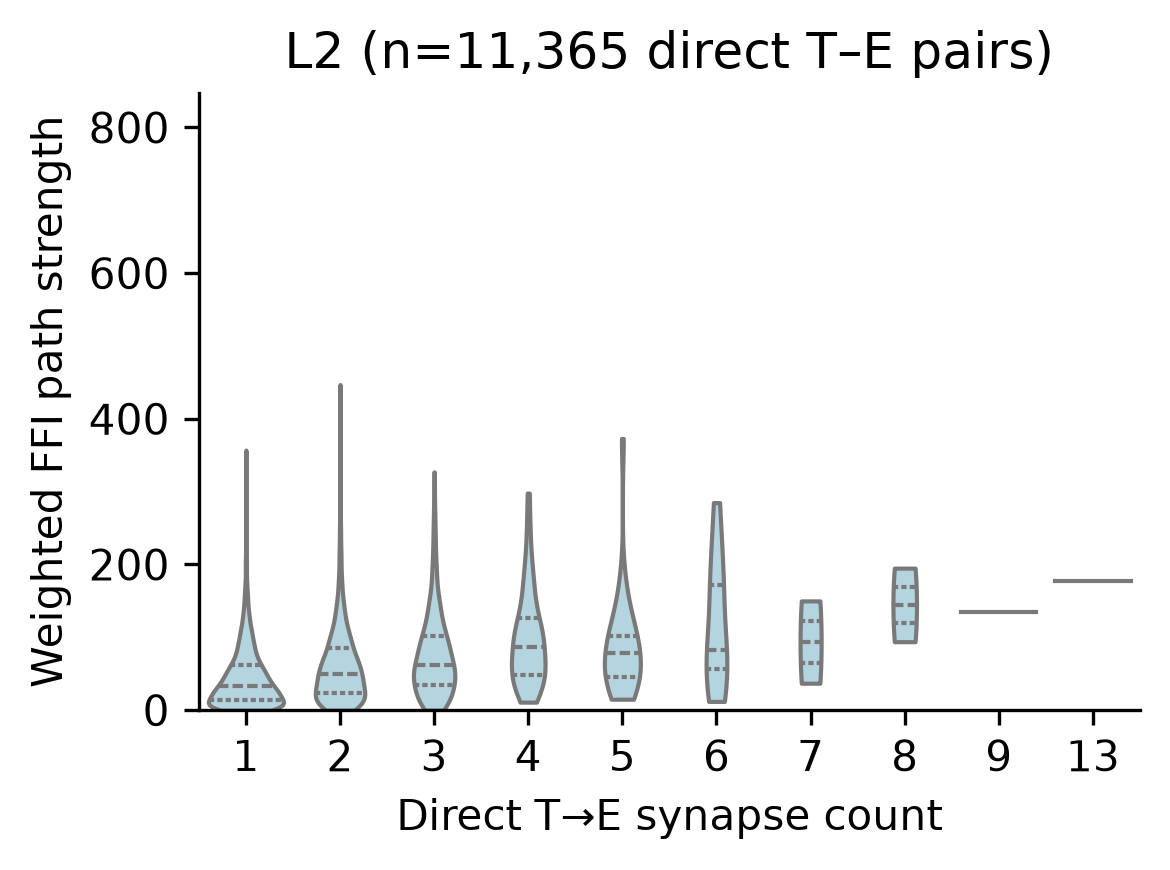

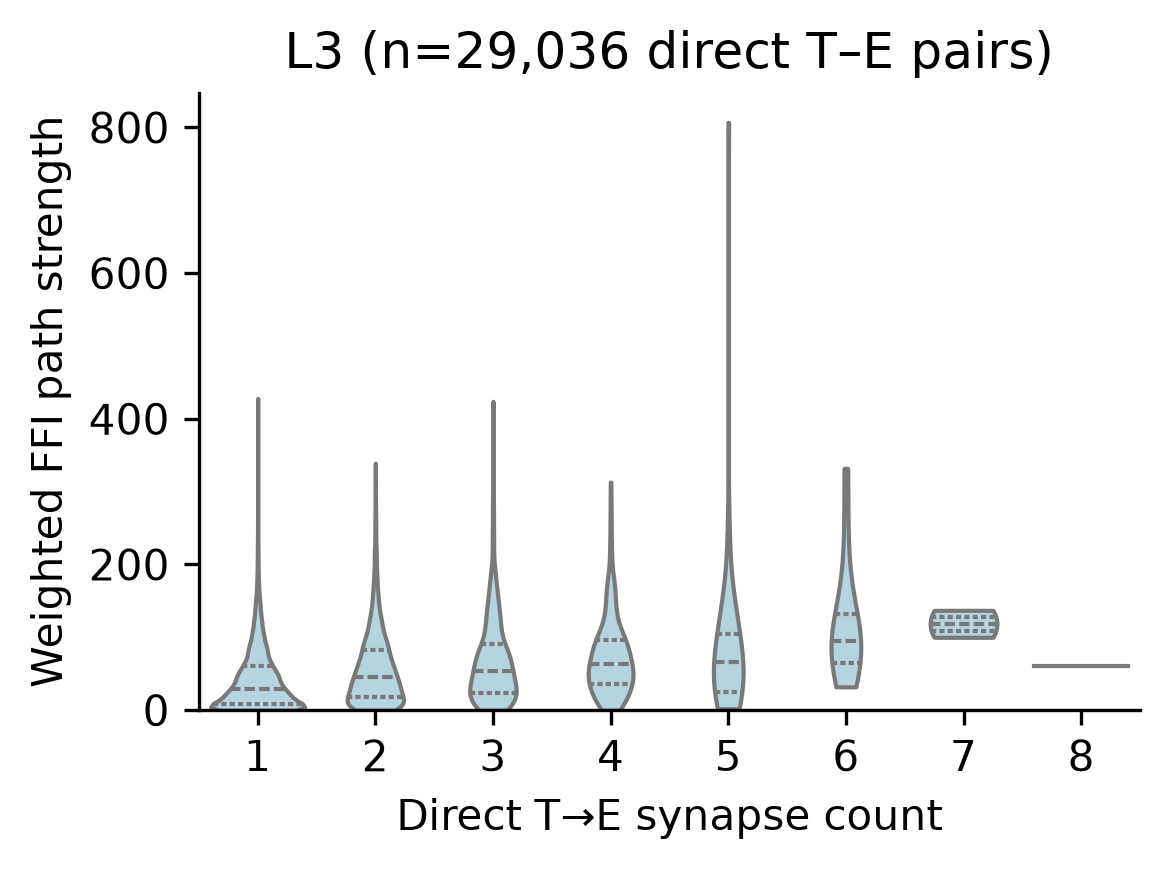

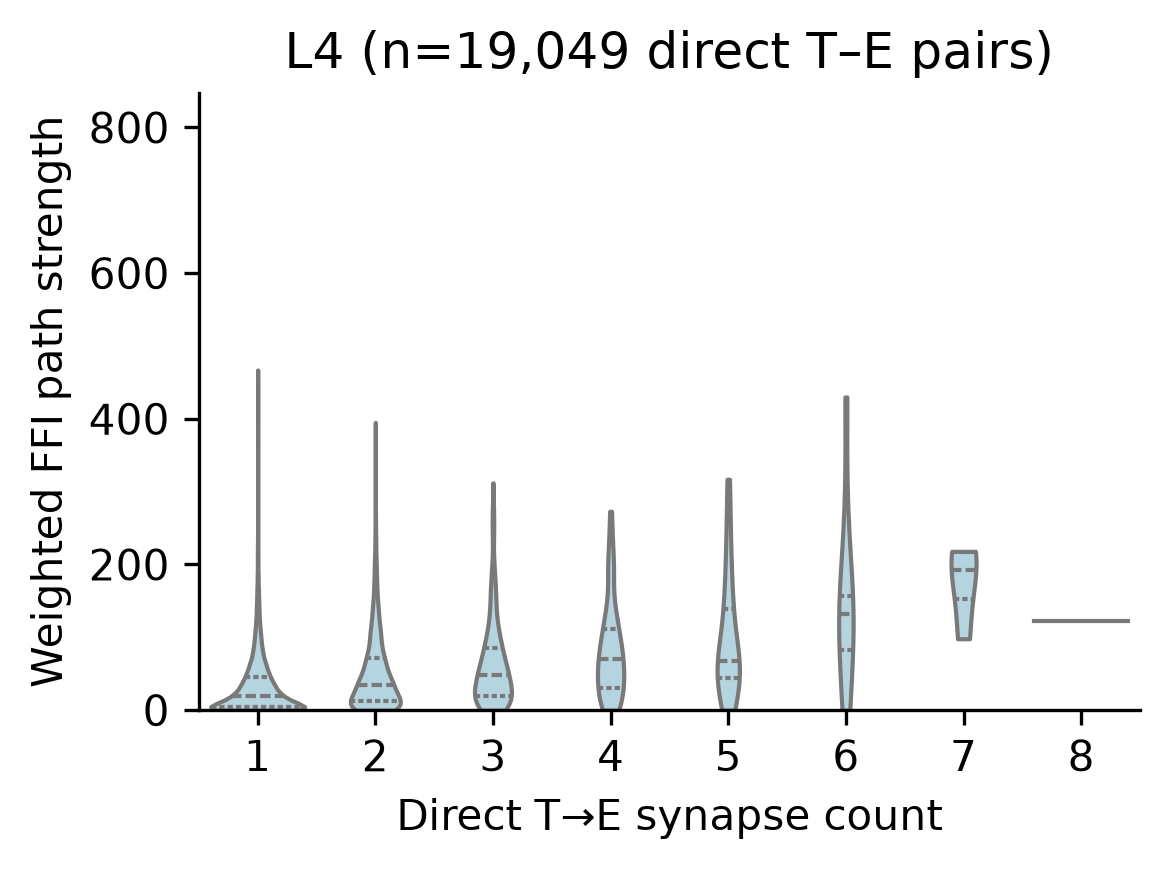

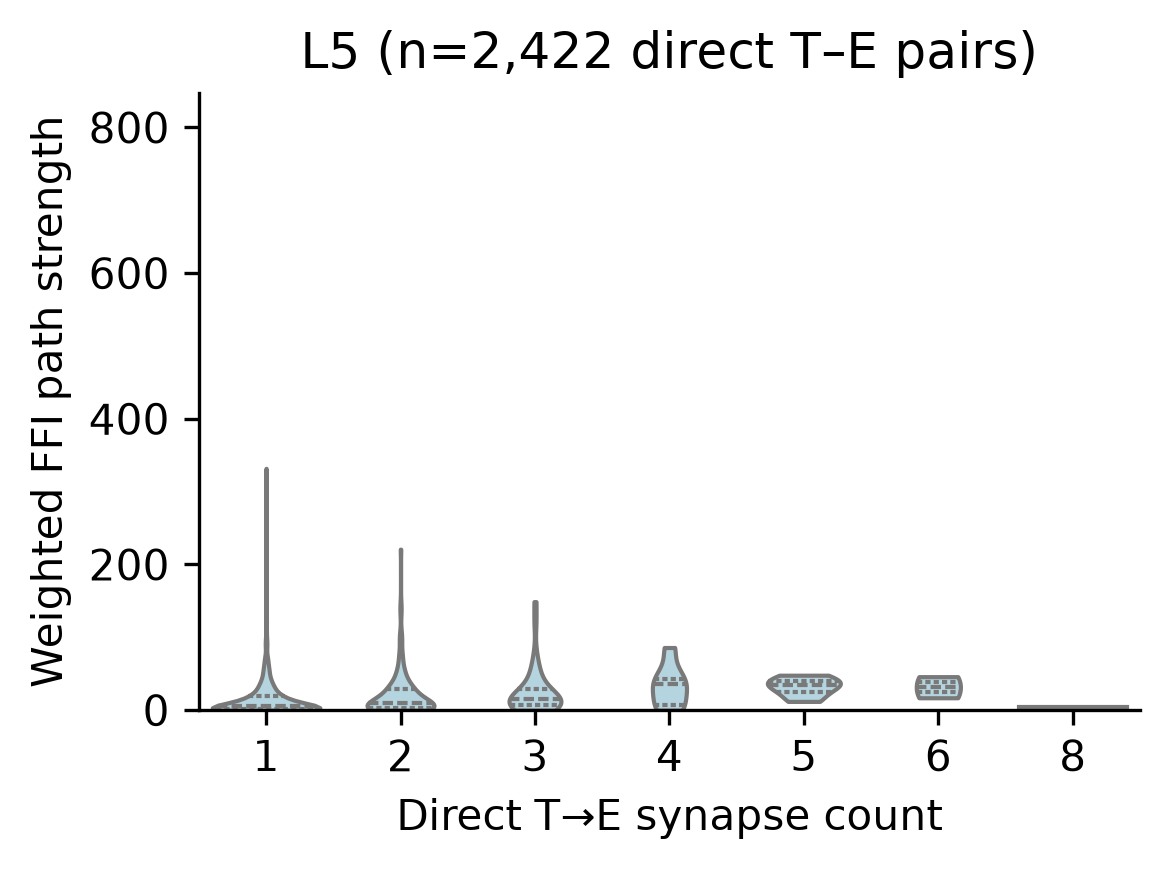

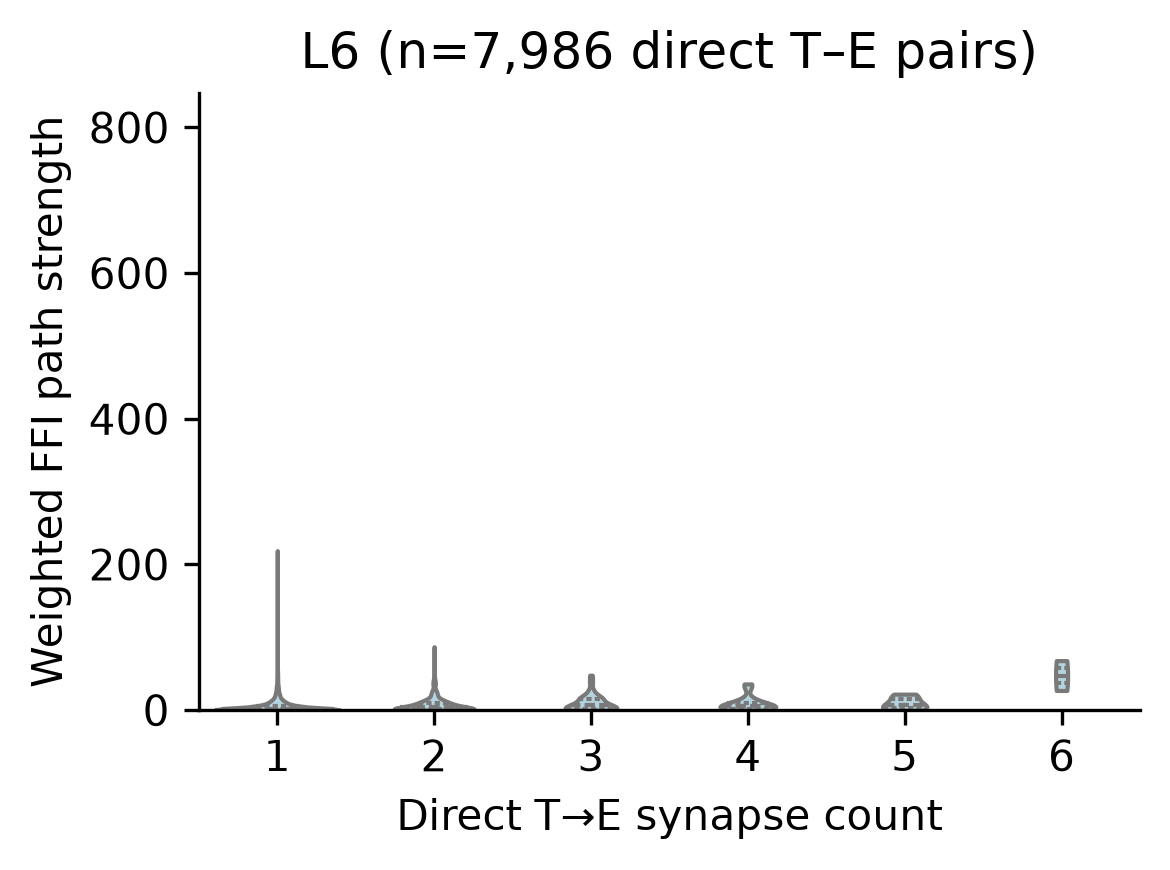

In [27]:
# Make one violin plot per layer
max_weighted = float(
    synapse_pair_df["weighted_path_strength"].max()
)

for layer in layer_order:
    layer_df = synapse_pair_df.loc[
        synapse_pair_df["layer"] == layer
    ].copy()

    if layer_df.empty:
        continue

    direct_order = sorted(
        layer_df["direct_synapses"].unique()
    )

    fig, ax = plt.subplots(figsize=(4,3), dpi=300)

    sns.violinplot(
        data=layer_df,
        x="direct_synapses",
        y="weighted_path_strength",
        order=direct_order,
        inner="quartile",
        cut=0,
        color="lightblue",
        linewidth=1,
        ax=ax,
    )

    ax.set_ylim(
        0,
        max_weighted * 1.05 if max_weighted > 0 else 1
    )
    ax.set_xlabel("Direct T→E synapse count")
    ax.set_ylabel("Weighted FFI path strength")
    ax.set_title(
        f"{layer} "
        f"(n={len(layer_df):,} direct T–E pairs)"
    )
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()

## Proofread cortical neurons and thalamic input coverage

In [28]:
# Select the proofread-status field relevant to postsynaptic input coverage.
if "status_dendrite" in proof.columns:
    proofread_status_col = "status_dendrite"
elif "status_axon" in proof.columns:
    proofread_status_col = "status_axon"
else:
    raise KeyError("No status_dendrite or status_axon column found in proof table.")

status = proof[proofread_status_col]
if pd.api.types.is_bool_dtype(status):
    is_proofread = status.fillna(False)
else:
    is_proofread = status.astype(str).str.lower().eq("true")

proofread_ids = proof.loc[is_proofread, "pt_root_id"].dropna().unique()
proofread_meta = ct.loc[
    ct["pt_root_id"].isin(proofread_ids),
    ["pt_root_id", "classification_system", "cell_type"],
].drop_duplicates("pt_root_id").copy()
proofread_meta["layer"] = proofread_meta["cell_type"].str.extract(r"(L[2-6])")

# Number of proofread E and I neurons in each layer.
proofread_counts = (
    proofread_meta.loc[
        proofread_meta["classification_system"].isin(["excitatory", "inhibitory"])
    ]
    .groupby(["layer", "classification_system"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(index=layer_order, fill_value=0)
    .reindex(columns=["excitatory", "inhibitory"], fill_value=0)
)

def make_thalamic_input_summary(cell_class, thalamic_target_ids):
    cells = proofread_meta.loc[
        proofread_meta["classification_system"] == cell_class
    ].copy()
    cells["has_thalamic_input"] = cells["pt_root_id"].isin(thalamic_target_ids)

    by_layer = (
        cells.dropna(subset=["layer"])
        .groupby("layer", observed=True)["has_thalamic_input"]
        .agg(n_with_input="sum", n_total="size")
        .reindex(layer_order)
    )
    by_layer[["n_with_input", "n_total"]] = (
        by_layer[["n_with_input", "n_total"]].fillna(0).astype(int)
    )
    by_layer["fraction"] = by_layer["n_with_input"].div(
        by_layer["n_total"].replace(0, np.nan)
    )

    overall = pd.DataFrame({
        "n_with_input": [int(cells["has_thalamic_input"].sum())],
        "n_total": [len(cells)],
        "fraction": [cells["has_thalamic_input"].mean()],
    }, index=["Overall"])
    return cells, pd.concat([overall, by_layer])

thal_input_E_ids = set(T_E_syn["post_pt_root_id"].dropna().unique())
thal_input_I_ids = set(T_I_syn["post_pt_root_id"].dropna().unique())
proofread_excitatory, excitatory_input_summary = make_thalamic_input_summary(
    "excitatory", thal_input_E_ids
)
proofread_inhibitory, inhibitory_input_summary = make_thalamic_input_summary(
    "inhibitory", thal_input_I_ids
)

print("Proofread status column used:", proofread_status_col)
print("Proofread typed neurons without an L2–L6 label:", proofread_meta["layer"].isna().sum())
print("\nFraction of proofread excitatory neurons with thalamic input:")
print(excitatory_input_summary)
print("\nFraction of proofread inhibitory neurons with thalamic input:")
print(inhibitory_input_summary)
print("\nProofread neuron counts by layer:")
proofread_counts

Proofread status column used: status_dendrite
Proofread typed neurons without an L2–L6 label: 560

Fraction of proofread excitatory neurons with thalamic input:
         n_with_input  n_total  fraction
Overall          2229     2523  0.883472
L2                493      544  0.906250
L3                792      803  0.986301
L4                612      628  0.974522
L5                218      345  0.631884
L6                114      203  0.561576

Fraction of proofread inhibitory neurons with thalamic input:
         n_with_input  n_total  fraction
Overall           491      560  0.876786
L2                  0        0       NaN
L3                  0        0       NaN
L4                  0        0       NaN
L5                  0        0       NaN
L6                  0        0       NaN

Proofread neuron counts by layer:


classification_system,excitatory,inhibitory
layer,,
L2,544,0
L3,803,0
L4,628,0
L5,345,0
L6,203,0


In [29]:
# Select the proofread-status field relevant to postsynaptic input coverage.
if "status_dendrite" in proof.columns:
    proofread_status_col = "status_dendrite"
elif "status_axon" in proof.columns:
    proofread_status_col = "status_axon"
else:
    raise KeyError("No status_dendrite or status_axon column found in proof table.")

status = proof[proofread_status_col]
if pd.api.types.is_bool_dtype(status):
    is_proofread = status.fillna(False)
else:
    is_proofread = status.astype(str).str.lower().eq("true")

proofread_ids = proof.loc[is_proofread, "pt_root_id"].dropna().unique()
proofread_meta = ct.loc[
    ct["pt_root_id"].isin(proofread_ids),
    ["pt_root_id", "classification_system", "cell_type"],
].drop_duplicates("pt_root_id").copy()
proofread_meta["layer"] = proofread_meta["cell_type"].str.extract(r"(L[2-6])")

# Number of proofread E and I neurons in each layer.
proofread_counts = (
    proofread_meta.loc[
        proofread_meta["classification_system"].isin(["excitatory", "inhibitory"])
    ]
    .groupby(["layer", "classification_system"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(index=layer_order, fill_value=0)
    .reindex(columns=["excitatory", "inhibitory"], fill_value=0)
)

def make_thalamic_input_summary(cell_class, thalamic_target_ids):
    cells = proofread_meta.loc[
        proofread_meta["classification_system"] == cell_class
    ].copy()
    cells["has_thalamic_input"] = cells["pt_root_id"].isin(thalamic_target_ids)

    by_layer = (
        cells.dropna(subset=["layer"])
        .groupby("layer", observed=True)["has_thalamic_input"]
        .agg(n_with_input="sum", n_total="size")
        .reindex(layer_order)
    )
    by_layer[["n_with_input", "n_total"]] = (
        by_layer[["n_with_input", "n_total"]].fillna(0).astype(int)
    )
    by_layer["fraction"] = by_layer["n_with_input"].div(
        by_layer["n_total"].replace(0, np.nan)
    )

    overall = pd.DataFrame({
        "n_with_input": [int(cells["has_thalamic_input"].sum())],
        "n_total": [len(cells)],
        "fraction": [cells["has_thalamic_input"].mean()],
    }, index=["Overall"])
    return cells, pd.concat([overall, by_layer])

thal_input_E_ids = set(T_E_syn["post_pt_root_id"].dropna().unique())
thal_input_I_ids = set(T_I_syn["post_pt_root_id"].dropna().unique())
proofread_excitatory, excitatory_input_summary = make_thalamic_input_summary(
    "excitatory", thal_input_E_ids
)
proofread_inhibitory, inhibitory_input_summary = make_thalamic_input_summary(
    "inhibitory", thal_input_I_ids
)

print("Proofread status column used:", proofread_status_col)
print("Proofread typed neurons without an L2–L6 label:", proofread_meta["layer"].isna().sum())
print("\nFraction of proofread excitatory neurons with thalamic input:")
print(excitatory_input_summary)
print("\nFraction of proofread inhibitory neurons with thalamic input:")
print(inhibitory_input_summary)
print("\nProofread neuron counts by layer:")
proofread_counts

Proofread status column used: status_dendrite
Proofread typed neurons without an L2–L6 label: 560

Fraction of proofread excitatory neurons with thalamic input:
         n_with_input  n_total  fraction
Overall          2229     2523  0.883472
L2                493      544  0.906250
L3                792      803  0.986301
L4                612      628  0.974522
L5                218      345  0.631884
L6                114      203  0.561576

Fraction of proofread inhibitory neurons with thalamic input:
         n_with_input  n_total  fraction
Overall           491      560  0.876786
L2                  0        0       NaN
L3                  0        0       NaN
L4                  0        0       NaN
L5                  0        0       NaN
L6                  0        0       NaN

Proofread neuron counts by layer:


classification_system,excitatory,inhibitory
layer,,
L2,544,0
L3,803,0
L4,628,0
L5,345,0
L6,203,0


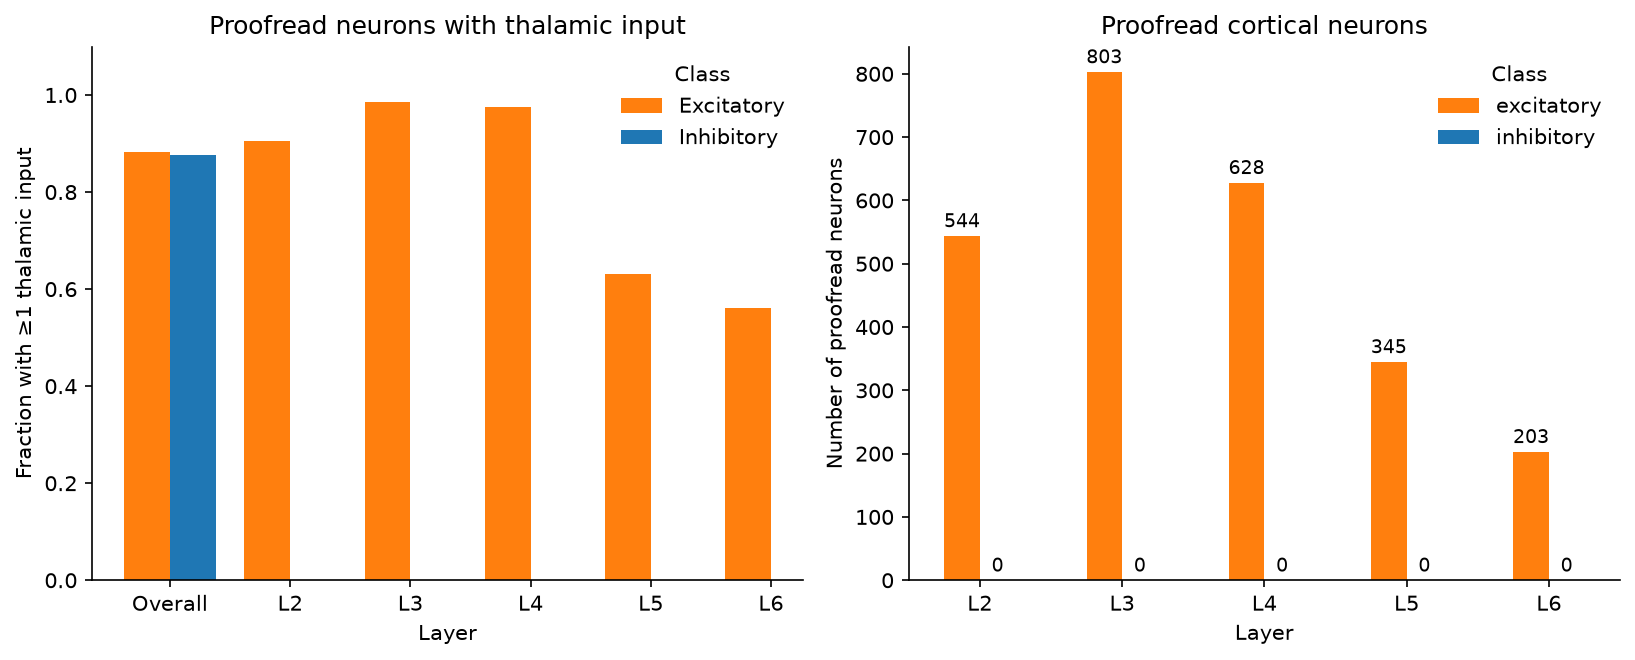

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), dpi=150)

# Fractions of proofread E and I neurons with at least one thalamic input.
fraction_order = ["Overall"] + layer_order
x = np.arange(len(fraction_order))
width = 0.38
E_plot = excitatory_input_summary.reindex(fraction_order)
I_plot = inhibitory_input_summary.reindex(fraction_order)
bars_E = axes[0].bar(
    x - width / 2, E_plot["fraction"], width,
    color="tab:orange", label="Excitatory",
)
bars_I = axes[0].bar(
    x + width / 2, I_plot["fraction"], width,
    color="tab:blue", label="Inhibitory",
)
axes[0].set_xticks(x, fraction_order)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel("Fraction with ≥1 thalamic input")
axes[0].set_xlabel("Layer")
axes[0].set_title("Proofread neurons with thalamic input")
axes[0].legend(title="Class", frameon=False)


# Number of proofread excitatory and inhibitory neurons by layer.
proofread_counts.plot(
    kind="bar", color=["tab:orange", "tab:blue"], ax=axes[1]
)
axes[1].set_xlabel("Layer")
axes[1].set_ylabel("Number of proofread neurons")
axes[1].set_title("Proofread cortical neurons")
axes[1].legend(title="Class", frameon=False)
for container in axes[1].containers:
    axes[1].bar_label(container, padding=2, fontsize=9)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

In [31]:
print("All rows in proof table:", len(proof))
print("\nDendrite status:")
print(proof["status_dendrite"].value_counts(dropna=False))

print("\nAxon status:")
print(proof["status_axon"].value_counts(dropna=False))

print("\nUnique E targets in W_TE:", W_TE.shape[1])
print("Unique I targets in W_TI:", W_TI.shape[1])

All rows in proof table: 3335

Dendrite status:
status_dendrite
True     3249
False      86
Name: count, dtype: Int64

Axon status:
status_axon
False    2062
True     1273
Name: count, dtype: Int64

Unique E targets in W_TE: 17397
Unique I targets in W_TI: 2752


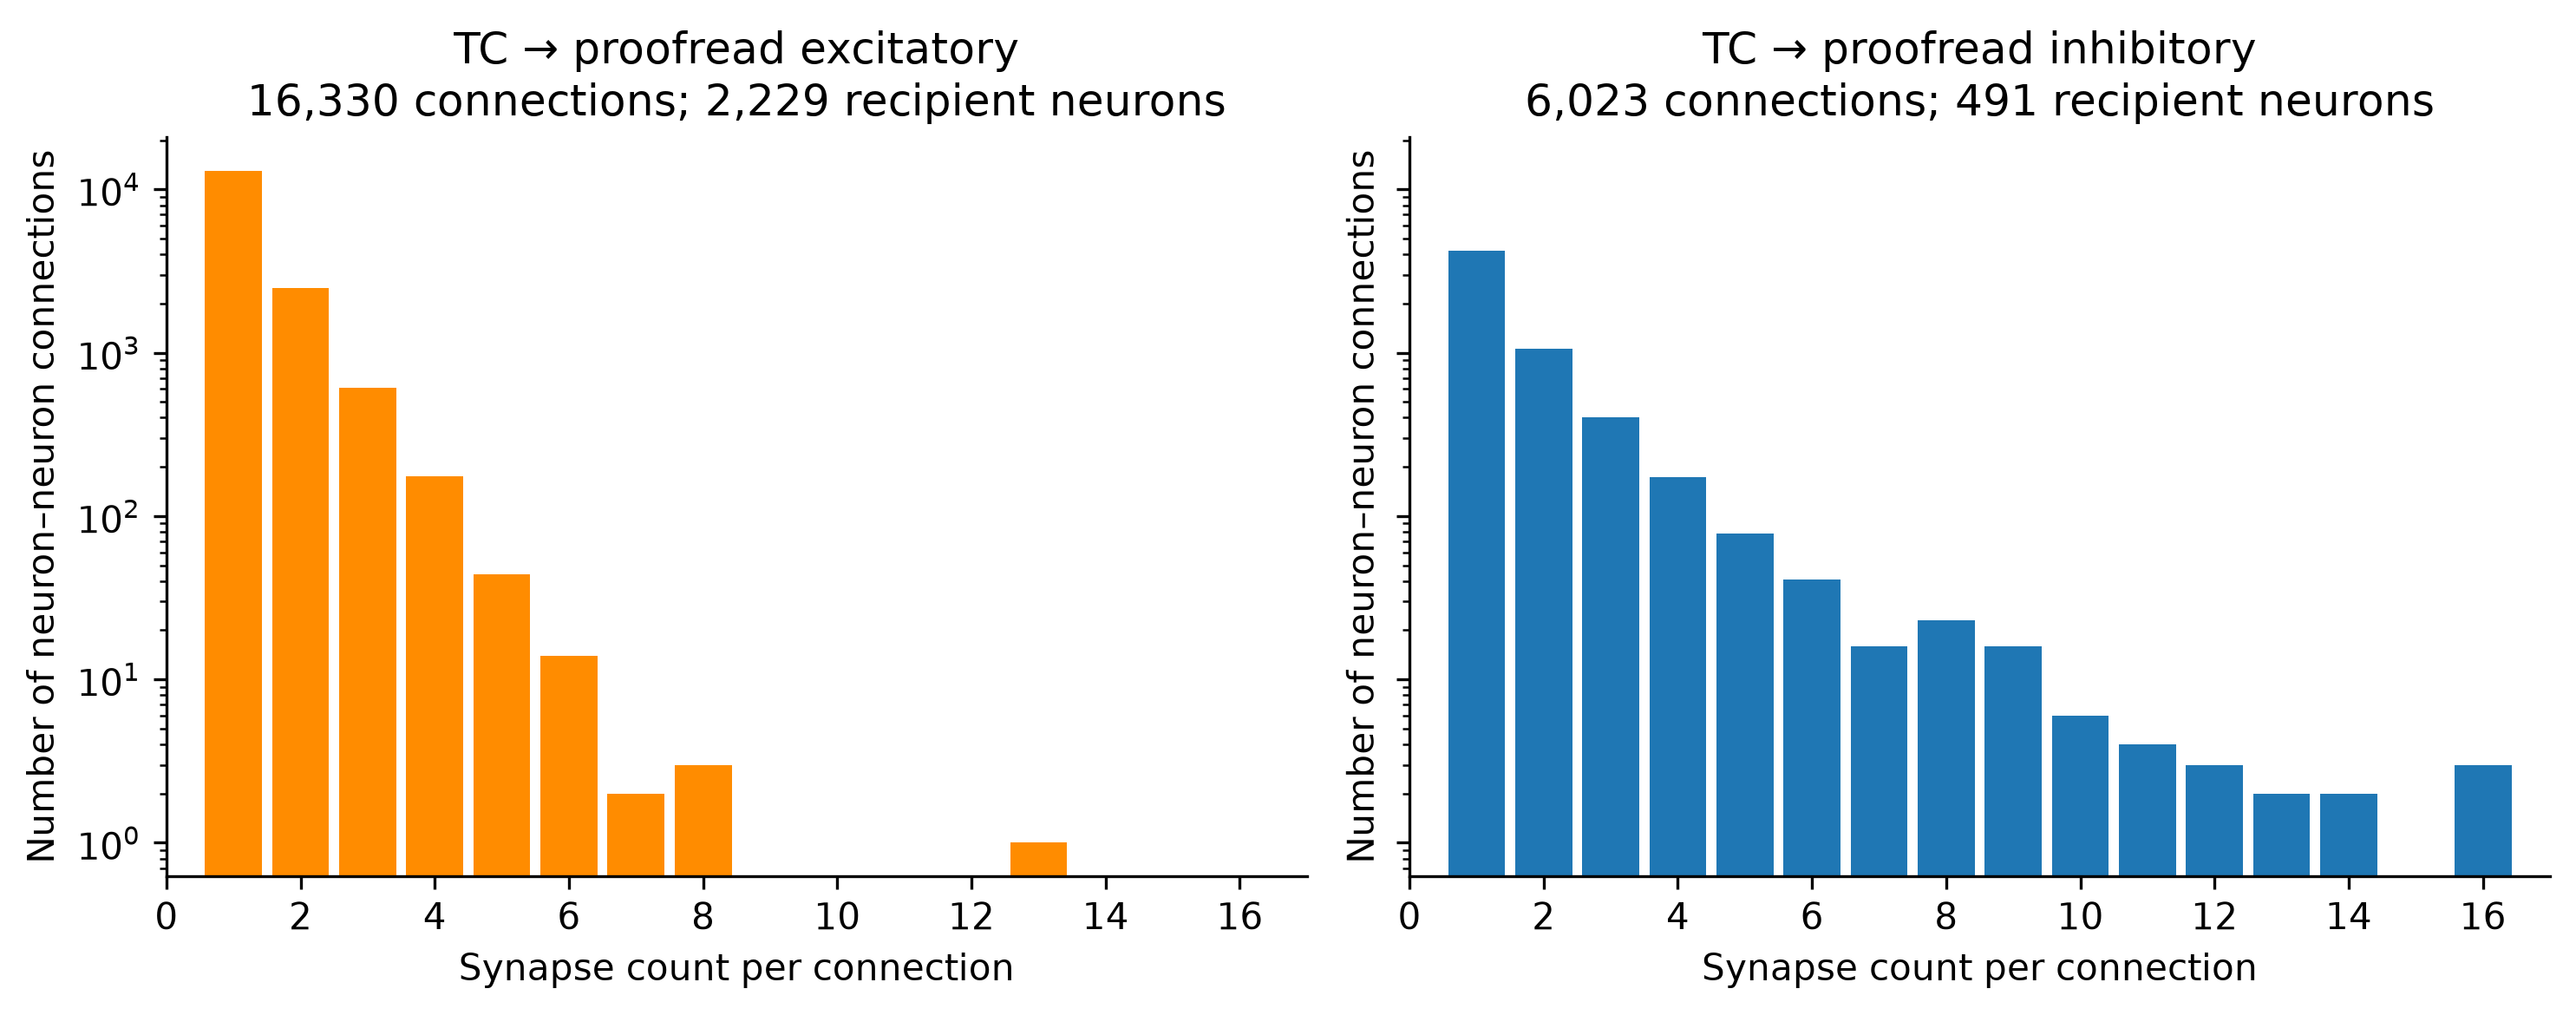

Proofread TC→E connection counts:
1     13007
2      2474
3       609
4       176
5        44
6        14
7         2
8         3
13        1
Name: count, dtype: int64

Proofread TC→I connection counts:
1     4195
2     1058
3      402
4      174
5       78
6       41
7       16
8       23
9       16
10       6
11       4
12       3
13       2
14       2
16       3
Name: count, dtype: int64


In [32]:
# proofread neurons 
proofread_E_ids = pd.Index(proofread_excitatory["pt_root_id"].unique())
proofread_I_ids = pd.Index(proofread_inhibitory["pt_root_id"].unique())

W_TE_proofread = W_TE.reindex(
    columns=W_TE.columns.intersection(proofread_E_ids)
)
W_TI_proofread = W_TI.reindex(
    columns=W_TI.columns.intersection(proofread_I_ids)
)

def nonzero_synapse_counts(matrix):
    values = matrix.to_numpy().ravel()
    return values[values > 0].astype(int)

synapse_counts_TE_proofread = nonzero_synapse_counts(W_TE_proofread)
synapse_counts_TI_proofread = nonzero_synapse_counts(W_TI_proofread)

if len(synapse_counts_TE_proofread) == 0 or len(synapse_counts_TI_proofread) == 0:
    raise ValueError(
        "No nonzero proofread-target connections found for TE or TI. "
        "Check materialization-version and root-ID alignment."
    )

max_count = int(max(
    synapse_counts_TE_proofread.max(),
    synapse_counts_TI_proofread.max(),
))
integer_bins = np.arange(0.5, max_count + 1.5, 1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=300, sharey=True)

axes[0].hist(
    synapse_counts_TE_proofread, bins=integer_bins,
    color="darkorange", rwidth=0.85,
)
axes[1].hist(
    synapse_counts_TI_proofread, bins=integer_bins,
    color="tab:blue", rwidth=0.85,
)

axes[0].set_title(
    f"TC → proofread excitatory\n"
    f"{len(synapse_counts_TE_proofread):,} connections; "
    f"{W_TE_proofread.shape[1]:,} recipient neurons"
)
axes[1].set_title(
    f"TC → proofread inhibitory\n"
    f"{len(synapse_counts_TI_proofread):,} connections; "
    f"{W_TI_proofread.shape[1]:,} recipient neurons"
)

for ax in axes:
    ax.set_xlabel("Synapse count per connection")
    ax.set_ylabel("Number of neuron–neuron connections")
    ax.set_xlim(0, max_count + 1)
    ax.set_yscale("log")
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print("Proofread TC→E connection counts:")
print(pd.Series(synapse_counts_TE_proofread).value_counts().sort_index())
print("\nProofread TC→I connection counts:")
print(pd.Series(synapse_counts_TI_proofread).value_counts().sort_index())